# Data Preparation / Feature Engineering

## Business objective and success criteria
This project aims to predict Remaining Useful Life (RUL) for aircraft engines so maintenance can be scheduled before failures occur. In practice, the model should help reduce unplanned downtime, avoid costly emergency repairs, and support proactive maintenance planning.

A good model should:
- predict RUL early enough to allow action before failure,
- keep prediction errors low enough that maintenance decisions are reliable,
- and generalize well to unseen engines rather than only memorizing the training set.

For this notebook, we use RMSE, MAE, and R² on a held-out validation set as the primary success criteria. Lower RMSE/MAE and higher R² indicate better predictive performance.


## Experiment: does the model rely too heavily on `cycle`?

This notebook is a copy of `step3_modeling_life_ratio.ipynb`, modified to test one
change: **`cycle` is excluded from the model's input features** (it's still kept as an
identifier column for grouping/plotting, exactly like `engine_id`, just never fed to
the model). SHAP analysis in step3 showed `cycle` was by far the largest contributor to
every prediction, which raises a leakage-like concern: the model may be mostly counting
elapsed cycles rather than learning from sensor degradation patterns. This notebook
reruns the same pipeline/tuning without `cycle` as a feature to see whether performance
holds up.

In the previous step1_eda.ipynb, we have performed some statistical analysis and draw insights on how to prepare our preliminary dataset. Including:

Train/Val split:
1. Splits dataset into training and validation before standardization, standardization should fit on train set only.
2. Must maintain local chronological order for each engine.

Data cleaning:
1. Compute life_ratio as labels
2. Removing the columns: settings1, settings2, settings3, engine_id (drop when training), T2, P2, farB, NF_dmd, PCNfR_dmd, and Nrc

Feature Scaling:
1. Sensor features are standardized using statistics computed exclusively from the training set.
2. The same transformation is applied to validation data to ensure consistency and prevent data leakage.

Feature Engineering: 
1. Compute rolling window statistics feature for sensors, grouped by engine_id.
2. Compute lags of current timestep.

In [1]:
import pandas as pd
import sys
sys.path.append("..")
from src.const import SENSOR_NAMES

columns = ['engine_id', 'cycle'] + SENSOR_NAMES

df = pd.read_csv("../data/raw/train_FD001.txt", sep=r'\s+', header=None,
                       usecols=range(len(columns)), names=columns, engine='python')

### Train/Val split

In [2]:
from sklearn.model_selection import train_test_split
# -----------------------------
# 1. Train/Validation split by engine_id
# -----------------------------
engine_ids = df["engine_id"].unique()

train_ids, val_ids = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_df = df[df["engine_id"].isin(train_ids)].copy()
val_df   = df[df["engine_id"].isin(val_ids)].copy()

# -----------------------------
# 2. Maintain local chronological order per engine
# -----------------------------
train_df = train_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)
val_df   = val_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)

# -----------------------------
# 3. Sanity checks
# -----------------------------
assert set(train_df["engine_id"]).isdisjoint(set(val_df["engine_id"])), "Leakage detected!"
assert train_df["cycle"].is_monotonic_increasing is False or True  # per-engine ordering enforced

print("Train engines:", train_df["engine_id"].nunique())
print("Val engines:", val_df["engine_id"].nunique())
print("Split complete without engine leakage.")

Train engines: 80
Val engines: 20
Split complete without engine leakage.


In [3]:
train_df

,engine_id,cycle,T2,T24,T30,T50,P2,P15,P30,Nf,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,...,9054.72,1.3,46.93,522.33,2388.06,8137.72,8.3905,0.03,391,2388
1,2,2,0.0043,-0.0003,100.0,518.67,641.82,1587.05,1393.13,14.62,...,9051.31,1.3,47.24,522.70,2387.98,8131.09,8.4167,0.03,392,2388
2,2,3,0.0018,0.0003,100.0,518.67,641.55,1588.32,1398.96,14.62,...,9054.24,1.3,47.22,522.58,2387.99,8140.58,8.3802,0.03,391,2388
3,2,4,0.0035,-0.0004,100.0,518.67,641.68,1584.15,1396.08,14.62,...,9058.01,1.3,47.10,522.49,2387.93,8140.44,8.4018,0.03,391,2388
4,2,5,0.0005,0.0004,100.0,518.67,641.73,1579.03,1402.52,14.62,...,9058.15,1.3,47.25,522.27,2387.94,8136.67,8.3867,0.03,390,2388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,9065.52,1.3,48.07,519.49,2388.26,8137.60,8.4956,0.03,397,2388
16557,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,9065.11,1.3,48.04,519.68,2388.22,8136.50,8.5139,0.03,395,2388
16558,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,9065.90,1.3,48.09,520.01,2388.24,8141.05,8.5646,0.03,398,2388
16559,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,9073.72,1.3,48.39,519.67,2388.23,8139.29,8.5389,0.03,395,2388


In [4]:
val_df

,engine_id,cycle,T2,T24,T30,T50,P2,P15,P30,Nf,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4065,91,131,-0.0010,-0.0000,100.0,518.67,642.98,1600.49,1427.11,14.62,...,9045.20,1.3,48.24,519.76,2388.28,8119.61,8.5282,0.03,395,2388
4066,91,132,-0.0025,-0.0003,100.0,518.67,643.91,1596.94,1428.41,14.62,...,9041.93,1.3,48.02,519.76,2388.30,8120.68,8.5323,0.03,397,2388
4067,91,133,0.0012,-0.0001,100.0,518.67,644.22,1602.83,1426.55,14.62,...,9049.93,1.3,48.07,519.35,2388.26,8120.11,8.5183,0.03,396,2388
4068,91,134,0.0004,0.0006,100.0,518.67,643.70,1606.40,1430.92,14.62,...,9052.04,1.3,48.20,519.43,2388.33,8119.01,8.5215,0.03,396,2388


In [5]:
train_df.nunique()

engine_id      80
cycle         362
T2            156
T24            13
T30             1
T50             1
P2            305
P15          2878
P30          3893
Nf              1
Nc              2
epr           501
Ps30           53
phi          5911
NRf             1
NRc           155
BPR           425
farB           55
htBleed      5652
Nf_dmd       1871
PCNfR_dmd       1
W31            13
W32             1
dtype: int64

In [6]:
val_df.nunique()

engine_id      20
cycle         269
T2            133
T24            13
T30             1
T50             1
P2            276
P15          1976
P30          2409
Nf              1
Nc              2
epr           454
Ps30           43
phi          2729
NRf             1
NRc           144
BPR           366
farB           45
htBleed      2678
Nf_dmd       1410
PCNfR_dmd       1
W31            11
W32             1
dtype: int64

### Preprocess

In [7]:
# -----------------------------
# 1. Compute life_ratio
# -----------------------------
def add_rul(df, engine_col="engine_id", cycle_col="cycle"):
    """
    Adds a Remaining Useful Life (RUL) column to a CMAPSS dataframe.

    RUL = max_cycle - current_cycle, computed independently for each engine.
    """
    df = df.copy()

    df["max_cycle"] = df.groupby(engine_col)[cycle_col].transform("max")
    df["RUL"] = df["max_cycle"] - df[cycle_col]

    df.drop(columns=["max_cycle"], inplace=True)

    return df

def add_life_ratio(df, engine_col="engine_id", cycle_col="cycle", rul_col="RUL"):
    """
    Adds a normalized life_ratio column to a CMAPSS dataframe.

    life_ratio = RUL / max_cycle, always in [0, 1]. It represents the
    fraction of remaining life: close to 1 early in an engine's life and
    0 at the failure cycle. Requires RUL to already be present.
    """
    df = df.copy()

    max_cycle = df.groupby(engine_col)[cycle_col].transform("max")
    df["life_ratio"] = df[rul_col] / max_cycle

    return df

# -----------------------------
# 2. Drop unwanted columns
# -----------------------------
def clean_features(df, cols_to_drop=[]):
    df = df.copy()
    # drop feature columns
    df = df.drop(columns=cols_to_drop, errors="ignore")
    return df

# -----------------------------
# 3. Full preprocessing pipeline
# -----------------------------
def preprocess(df, cols_to_drop=[]):
    df = add_rul(df)
    df = add_life_ratio(df)
    # RUL is dropped so it can't leak into the features; life_ratio is the target now
    df = df.drop(columns=["RUL"])
    df = clean_features(df, cols_to_drop)
    return df

In [8]:
cols_to_drop = [
    "setting_1", "setting_2", "setting_3",
    "T2", "P2", "farB", "Nf_dmd", "PCNfR_dmd", "Nc",
    "P15", "P30", "epr"
]
# cols_to_drop = []
train_df = preprocess(train_df, cols_to_drop=cols_to_drop)
val_df   = preprocess(val_df, cols_to_drop=cols_to_drop)

In [9]:
train_df

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,2,1,0.0006,100.0,518.67,14.62,2388.01,9054.72,1.3,46.93,522.33,8137.72,391,2388,0.996516
1,2,2,-0.0003,100.0,518.67,14.62,2387.98,9051.31,1.3,47.24,522.70,8131.09,392,2388,0.993031
2,2,3,0.0003,100.0,518.67,14.62,2388.04,9054.24,1.3,47.22,522.58,8140.58,391,2388,0.989547
3,2,4,-0.0004,100.0,518.67,14.62,2387.98,9058.01,1.3,47.10,522.49,8140.44,391,2388,0.986063
4,2,5,0.0004,100.0,518.67,14.62,2388.03,9058.15,1.3,47.25,522.27,8136.67,390,2388,0.982578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,-0.0003,100.0,518.67,14.62,2388.19,9065.52,1.3,48.07,519.49,8137.60,397,2388,0.020000
16557,100,197,-0.0005,100.0,518.67,14.62,2388.23,9065.11,1.3,48.04,519.68,8136.50,395,2388,0.015000
16558,100,198,0.0000,100.0,518.67,14.62,2388.24,9065.90,1.3,48.09,520.01,8141.05,398,2388,0.010000
16559,100,199,0.0003,100.0,518.67,14.62,2388.25,9073.72,1.3,48.39,519.67,8139.29,395,2388,0.005000


In [10]:
val_df

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,1,1,-0.0004,100.0,518.67,14.62,2388.06,9046.19,1.3,47.47,521.66,8138.62,392,2388,0.994792
1,1,2,-0.0003,100.0,518.67,14.62,2388.04,9044.07,1.3,47.49,522.28,8131.49,392,2388,0.989583
2,1,3,0.0003,100.0,518.67,14.62,2388.08,9052.94,1.3,47.27,522.42,8133.23,390,2388,0.984375
3,1,4,0.0000,100.0,518.67,14.62,2388.11,9049.48,1.3,47.13,522.86,8133.83,392,2388,0.979167
4,1,5,-0.0002,100.0,518.67,14.62,2388.06,9055.15,1.3,47.28,522.19,8133.80,393,2388,0.973958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4065,91,131,-0.0000,100.0,518.67,14.62,2388.26,9045.20,1.3,48.24,519.76,8119.61,395,2388,0.029630
4066,91,132,-0.0003,100.0,518.67,14.62,2388.30,9041.93,1.3,48.02,519.76,8120.68,397,2388,0.022222
4067,91,133,-0.0001,100.0,518.67,14.62,2388.29,9049.93,1.3,48.07,519.35,8120.11,396,2388,0.014815
4068,91,134,0.0006,100.0,518.67,14.62,2388.27,9052.04,1.3,48.20,519.43,8119.01,396,2388,0.007407


### Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Define sensor columns
# -----------------------------
def get_sensor_columns(df):
    return df.select_dtypes(include=["float64", "int64"]).columns.drop(
        ["life_ratio", "cycle", "engine_id"], errors="ignore"
    )

sensor_cols = get_sensor_columns(train_df)

# -----------------------------
# 2. Fit scaler ONLY on training set
# -----------------------------
scaler = StandardScaler()

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()

scaler.fit(train_df_scaled[sensor_cols])

train_df_scaled[sensor_cols] = scaler.transform(train_df_scaled[sensor_cols])
val_df_scaled[sensor_cols] = scaler.transform(val_df_scaled[sensor_cols])

# -----------------------------
# 3. Sanity check
# -----------------------------
print("Scaling complete.")
print("Train shape:", train_df_scaled.shape)
print("Val shape:", val_df_scaled.shape)

Scaling complete.
Train shape: (16561, 15)
Val shape: (4070, 15)


In [12]:
train_df_scaled

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,2,1,2.043793,0.0,0.0,-5.329071e-15,-1.221017,-0.471297,-2.220446e-16,-2.294365,1.242127,-0.315944,-1.426246,0.0,0.996516
1,2,2,-1.031739,0.0,0.0,-5.329071e-15,-1.645675,-0.621789,-2.220446e-16,-1.127747,1.745551,-0.654442,-0.779529,0.0,0.993031
2,2,3,1.018616,0.0,0.0,-5.329071e-15,-0.796358,-0.492481,-2.220446e-16,-1.203012,1.582278,-0.169925,-1.426246,0.0,0.989547
3,2,4,-1.373465,0.0,0.0,-5.329071e-15,-1.645675,-0.326102,-2.220446e-16,-1.654606,1.459824,-0.177072,-1.426246,0.0,0.986063
4,2,5,1.360341,0.0,0.0,-5.329071e-15,-0.937911,-0.319923,-2.220446e-16,-1.090114,1.160491,-0.369552,-2.072963,0.0,0.982578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,-1.031739,0.0,0.0,-5.329071e-15,1.326935,0.005332,-2.220446e-16,1.995779,-2.621987,-0.322070,2.454058,0.0,0.020000
16557,100,197,-1.715191,0.0,0.0,-5.329071e-15,1.893147,-0.012762,-2.220446e-16,1.882880,-2.363472,-0.378231,1.160624,0.0,0.015000
16558,100,198,-0.006562,0.0,0.0,-5.329071e-15,2.034700,0.022102,-2.220446e-16,2.071044,-1.914473,-0.145928,3.100776,0.0,0.010000
16559,100,199,1.018616,0.0,0.0,-5.329071e-15,2.176253,0.367217,-2.220446e-16,3.200030,-2.377078,-0.235786,1.160624,0.0,0.005000


In [13]:
train_df_scaled.describe()

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
count,16561.000000,16561.000000,1.656100e+04,16561.0,16561.0,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,16561.0,16561.000000
mean,53.022704,109.377815,-2.231038e-17,0.0,0.0,-5.329071e-15,-1.117482e-12,1.123757e-14,-2.220446e-16,-3.514743e-15,1.054938e-13,3.933492e-15,-1.643417e-14,0.0,0.497585
std,29.258544,69.639875,1.000030e+00,0.0,0.0,0.000000e+00,1.000030e+00,1.000030e+00,0.000000e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,0.0,0.288681
min,2.000000,1.000000,-2.056917e+00,0.0,0.0,-5.329071e-15,-2.778098e+00,-1.927223e+00,-2.220446e-16,-2.595427e+00,-3.710470e+00,-2.244824e+00,-3.366398e+00,0.0,0.000000
25%,27.000000,52.000000,-6.900133e-01,0.0,0.0,-5.329071e-15,-6.548050e-01,-5.410265e-01,-2.220446e-16,-7.137854e-01,-6.218996e-01,-5.313983e-01,-7.795285e-01,0.0,0.247525
50%,55.000000,104.000000,-6.561730e-03,0.0,0.0,-5.329071e-15,-8.859342e-02,-1.981182e-01,-2.220446e-16,-1.116601e-01,9.922029e-02,-1.592030e-01,-1.328112e-01,0.0,0.497512
75%,79.000000,157.000000,1.018616e+00,0.0,0.0,-5.329071e-15,6.191710e-01,1.761241e-01,-2.220446e-16,6.033638e-01,7.250979e-01,2.232035e-01,5.139062e-01,0.0,0.747525
max,100.000000,362.000000,2.043793e+00,0.0,0.0,-5.329071e-15,6.564392e+00,7.908111e+00,-2.220446e-16,3.689256e+00,2.670761e+00,7.648730e+00,4.394210e+00,0.0,0.997238


In [14]:
val_df_scaled.describe()

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
count,4070.000000,4070.000000,4070.000000,4070.0,4070.0,4.070000e+03,4070.000000,4070.000000,4.070000e+03,4070.000000,4070.000000,4070.000000,4070.000000,4070.0,4070.000000
mean,45.337346,106.488698,0.007460,0.0,0.0,-5.329071e-15,0.028196,-0.034953,-2.220446e-16,0.028562,-0.024872,-0.040245,0.017348,0.0,0.497543
std,28.278657,65.659973,1.007403,0.0,0.0,0.000000e+00,1.023892,0.862803,0.000000e+00,1.025404,1.017466,0.859039,1.008026,0.0,0.288707
min,1.000000,1.000000,-2.056917,0.0,0.0,-5.329071e-15,-2.494992,-1.420143,-2.220446e-16,-2.407263,-3.207046,-1.683723,-2.719681,0.0,0.000000
25%,19.000000,51.000000,-1.031739,0.0,0.0,-5.329071e-15,-0.796358,-0.546764,-2.220446e-16,-0.751418,-0.676324,-0.584879,-0.779529,0.0,0.246874
50%,45.000000,102.000000,-0.006562,0.0,0.0,-5.329071e-15,0.052959,-0.256814,-2.220446e-16,-0.036394,0.031190,-0.215364,-0.132811,0.0,0.497636
75%,77.000000,154.000000,1.018616,0.0,0.0,-5.329071e-15,0.760724,0.185723,-2.220446e-16,0.678629,0.738704,0.230224,0.513906,0.0,0.747179
max,91.000000,269.000000,2.043793,0.0,0.0,-5.329071e-15,3.450229,4.442398,-2.220446e-16,3.726889,2.303398,4.438354,3.747493,0.0,0.996283


### Feature Engineering (Adding rolling window and lags):
- Useful for Tree models

In [15]:
import numpy as np

WINDOW = 5
LAGS = [1, 2]

def add_time_series_features(df, sensor_cols):
    df = df.copy()
    df = df.sort_values(["engine_id", "cycle"])

    group_cols = ["engine_id"]

    # -------------------------
    # Rolling mean features
    # -------------------------
    for col in sensor_cols:
        df[f"{col}_roll_mean"] = (
            df.groupby(group_cols)[col]
              .transform(lambda x: x.rolling(WINDOW, min_periods=1).mean())
        )

    # -------------------------
    # Lag features
    # -------------------------
    for col in sensor_cols:
        for lag in LAGS:
            df[f"{col}_lag{lag}"] = (
                df.groupby(group_cols)[col]
                  .shift(lag)
            )

    return df

In [16]:
def fit_feature_selector(train_df, target="life_ratio", top_k=10):
    # keep ONLY numeric columns
    numeric_df = train_df.select_dtypes(include=["number"]).copy()

    feature_cols = numeric_df.columns.drop([target, "cycle"], errors="ignore")

    corr = numeric_df[feature_cols].corrwith(numeric_df[target]).abs()
    var = numeric_df[feature_cols].var()

    score = corr * var

    score_df = (
        pd.DataFrame({
            "correlation": corr,
            "variance": var,
            "score": score
        })
        .sort_values(by="score", ascending=False)
    )

    print("\n===== Feature Scores (Top 20) =====")
    print(score_df.head(20))

    # -------------------------
    # top-k logic fix
    # -------------------------
    if top_k == -1:
        top_features = score_df.index.tolist()
        print("\nSelected ALL features")
    else:
        top_features = score_df.head(top_k).index.tolist()
        print(f"\nSelected Top {top_k} Features:")

    print(top_features)

    return top_features

In [17]:
def get_sensor_columns(df):
    exclude = {"life_ratio", "cycle", "engine_id"}

    return [
        c for c in df.select_dtypes(include=["number"]).columns
        if c not in exclude
    ]

In [18]:
def apply_feature_selection(df, selected_features, target="life_ratio"):
    if "cycle" not in selected_features:
        selected_features.append("cycle")
    if "engine_id" not in selected_features:
        selected_features.append("engine_id")
    keep_cols = [target] + selected_features
    return df[keep_cols].copy()

In [19]:
def feature_engineering_pipeline(train_df, val_df, top_k=10):
    # -------------------------
    # 1. sensor columns from TRAIN ONLY
    # -------------------------
    sensor_cols = get_sensor_columns(train_df)

    # -------------------------
    # 2. Feature engineering
    # -------------------------
    train_fe = add_time_series_features(train_df, sensor_cols)
    val_fe   = add_time_series_features(val_df, sensor_cols)
    # train_fe = train_df
    # val_fe = val_df

    # handle NaNs from lag
    train_fe = train_fe.dropna().reset_index(drop=True)
    val_fe   = val_fe.dropna().reset_index(drop=True)

    # -------------------------
    # 3. Feature selection (TRAIN ONLY)
    # -------------------------
    selected_features = fit_feature_selector(train_fe, top_k=top_k)

    print("Top selected features:", selected_features)

    # -------------------------
    # 4. Apply selection
    # -------------------------
    train_final = apply_feature_selection(train_fe, selected_features)
    val_final   = apply_feature_selection(val_fe, selected_features)

    return train_final, val_final, selected_features

In [20]:
train_final, val_final, selected_features = feature_engineering_pipeline(
    train_df_scaled,
    val_df_scaled,
    top_k=10
)


===== Feature Scores (Top 20) =====
                correlation    variance     score
engine_id          0.001105  856.267425  0.946241
NRc                0.732691    0.999654  0.732438
NRc_lag1           0.727760    0.975917  0.710233
BPR                0.705401    1.000597  0.705822
NRc_lag2           0.722854    0.952378  0.688430
BPR_lag1           0.699790    0.976480  0.683331
BPR_lag2           0.694276    0.955295  0.663239
NRc_roll_mean      0.771527    0.836765  0.645587
W31                0.643505    0.999805  0.643379
W31_lag1           0.636693    0.978922  0.623273
BPR_roll_mean      0.748687    0.821831  0.615295
W31_lag2           0.631028    0.962284  0.607229
Ps30               0.576890    1.000793  0.577347
Ps30_lag1          0.571022    0.975361  0.556952
Ps30_lag2          0.564577    0.954338  0.538797
W31_roll_mean      0.761281    0.662069  0.504021
Ps30_roll_mean     0.613816    0.809172  0.496682
phi                0.444372    1.006915  0.447444
phi_lag1     

/home/adamtay/miniforge3/envs/jabil/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/adamtay/miniforge3/envs/jabil/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [21]:
train_final

,life_ratio,engine_id,NRc,NRc_lag1,BPR,NRc_lag2,BPR_lag1,BPR_lag2,NRc_roll_mean,W31,W31_lag1,cycle
0,0.989547,2,-1.203012,-1.127747,1.582278,-2.294365,1.745551,1.242127,-1.541708,-1.426246,-0.779529,3
1,0.986063,2,-1.654606,-1.203012,1.459824,-1.127747,1.582278,1.745551,-1.569932,-1.426246,-1.426246,4
2,0.982578,2,-1.090114,-1.654606,1.160491,-1.203012,1.459824,1.582278,-1.473969,-2.072963,-1.426246,5
3,0.979094,2,-1.842771,-1.090114,1.881611,-1.654606,1.160491,1.459824,-1.383650,-0.779529,-2.072963,6
4,0.975610,2,-1.654606,-1.842771,0.983613,-1.090114,1.881611,1.160491,-1.489022,-1.426246,-0.779529,7
...,...,...,...,...,...,...,...,...,...,...,...,...
16396,0.020000,100,1.995779,2.560271,-2.621987,2.183943,-2.322654,-2.540351,2.319421,2.454058,0.513906,196
16397,0.015000,100,1.882880,1.995779,-2.363472,2.560271,-2.621987,-2.322654,2.214049,1.160624,2.454058,197
16398,0.010000,100,2.071044,1.882880,-1.914473,1.995779,-2.363472,-2.621987,2.138784,3.100776,1.160624,198
16399,0.005000,100,3.200030,2.071044,-2.377078,1.882880,-1.914473,-2.363472,2.342001,1.160624,3.100776,199


In [22]:
val_final

,life_ratio,engine_id,NRc,NRc_lag1,BPR,NRc_lag2,BPR_lag1,BPR_lag2,NRc_roll_mean,W31,W31_lag1,cycle
0,0.984375,1,-1.014848,-0.186926,1.364582,-0.262191,1.174097,0.330523,-0.487988,-2.072963,-0.779529,3
1,0.979167,1,-1.541708,-1.014848,1.963247,-0.186926,1.364582,1.174097,-0.751418,-0.779529,-2.072963,4
2,0.973958,1,-0.977215,-1.541708,1.051643,-1.014848,1.963247,1.364582,-0.796578,-0.132811,-0.779529,5
3,0.968750,1,-1.428809,-0.977215,0.357735,-1.541708,1.051643,1.963247,-1.029901,-1.426246,-0.132811,6
4,0.963542,1,-0.676153,-1.428809,1.228521,-0.977215,0.357735,1.051643,-1.127747,-0.779529,-1.426246,7
...,...,...,...,...,...,...,...,...,...,...,...,...
4025,0.029630,91,2.635537,2.372107,-2.254624,1.769982,-2.200200,-2.390684,2.409740,1.160624,1.160624,131
4026,0.022222,91,1.807615,2.635537,-2.254624,2.372107,-2.254624,-2.200200,2.221576,2.454058,1.160624,132
4027,0.014815,91,1.995779,1.807615,-2.812471,2.635537,-2.254624,-2.254624,2.116204,1.807341,2.454058,133
4028,0.007407,91,2.485006,1.995779,-2.703623,1.807615,-2.812471,-2.254624,2.259209,1.807341,1.807341,134


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

TARGET = "life_ratio"

X_train = train_final.drop(columns=[TARGET, "engine_id", "cycle"], errors="ignore")
y_train = train_final[TARGET]

X_val = val_final.drop(columns=[TARGET, "engine_id", "cycle"], errors="ignore")
y_val = val_final[TARGET]

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_val = rf.predict(X_val)

In [24]:
def evaluate(y_true, y_pred, name="Dataset"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{ name } Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R2  : {r2:.4f}")

evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 0.0654
MAE : 0.0506
R2  : 0.9476

Validation Performance:
RMSE: 0.1806
MAE : 0.1400
R2  : 0.6007


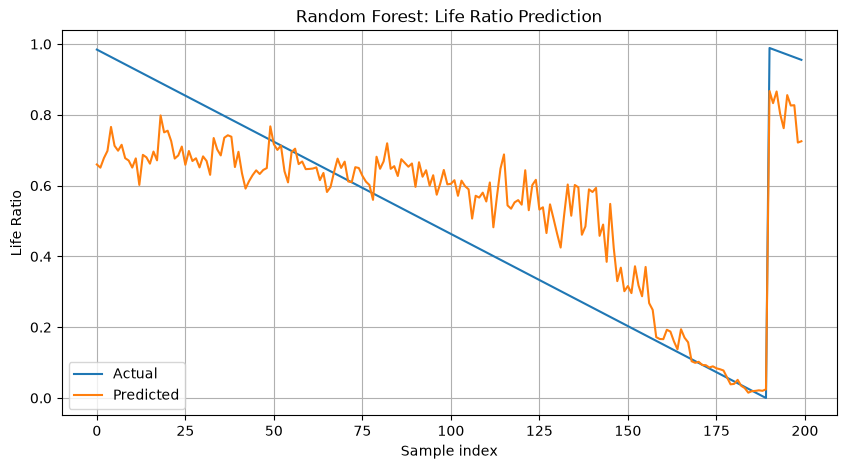

Mean validation residual (Actual - Predicted): 0.006135091323364066


In [25]:
# Plot prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_pred_val[:200], label="Predicted")
plt.title("Random Forest: Life Ratio Prediction")
plt.ylabel("Life Ratio")
plt.xlabel("Sample index")
plt.legend()
plt.grid()
plt.show()

print("Mean validation residual (Actual - Predicted):", (y_val - y_pred_val).mean())

Without `cycle`, the untrained-tuning baseline Random Forest's validation RMSE jumps from
0.0601 (with `cycle`, step3) to **0.1806**, and R² collapses from 0.9557 to **0.6007**. The
mean residual is still small, but the *spread* of errors is now far wider (see the model
comparison table and error analysis below) -- removing `cycle` costs far more accuracy than
a small bias number suggests.

### Hyperparameter tuning with Optuna

In [26]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

/home/adamtay/miniforge3/envs/jabil/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
# Hyperparameter tuning random forest
besr_rf = None
best_rmse = None

def rf_objective(trial):
    global besr_rf, best_rmse

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 5, 100),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.5, 0.8, None]
        ),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    if best_rmse is None or rmse < best_rmse:
        best_rmse = rmse
        besr_rf = model

    return rmse


In [28]:
study = optuna.create_study(direction="minimize")
study.optimize(rf_objective, n_trials=100)

[I 2026-07-06 15:43:31,695] A new study created in memory with name: no-name-a45e9845-1844-4654-9c96-8c237c629e1d


[I 2026-07-06 15:43:32,477] Trial 0 finished with value: 0.18169439998065479 and parameters: {'n_estimators': 238, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 0.8, 'bootstrap': False}. Best is trial 0 with value: 0.18169439998065479.


[I 2026-07-06 15:43:33,092] Trial 1 finished with value: 0.1803476141063636 and parameters: {'n_estimators': 258, 'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.8, 'bootstrap': False}. Best is trial 1 with value: 0.1803476141063636.


[I 2026-07-06 15:43:33,523] Trial 2 finished with value: 0.17931883084915756 and parameters: {'n_estimators': 248, 'max_depth': 66, 'min_samples_split': 16, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': False}. Best is trial 2 with value: 0.17931883084915756.


[I 2026-07-06 15:43:34,327] Trial 3 finished with value: 0.17915661887429005 and parameters: {'n_estimators': 501, 'max_depth': 52, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 3 with value: 0.17915661887429005.


[I 2026-07-06 15:43:34,608] Trial 4 finished with value: 0.17993927750094932 and parameters: {'n_estimators': 127, 'max_depth': 52, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': False}. Best is trial 3 with value: 0.17915661887429005.


[I 2026-07-06 15:43:35,225] Trial 5 finished with value: 0.17855247639075866 and parameters: {'n_estimators': 397, 'max_depth': 66, 'min_samples_split': 17, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 5 with value: 0.17855247639075866.


[I 2026-07-06 15:43:35,481] Trial 6 finished with value: 0.17956655351213388 and parameters: {'n_estimators': 122, 'max_depth': 71, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False}. Best is trial 5 with value: 0.17855247639075866.


[I 2026-07-06 15:43:35,885] Trial 7 finished with value: 0.1794423631734368 and parameters: {'n_estimators': 197, 'max_depth': 14, 'min_samples_split': 16, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': False}. Best is trial 5 with value: 0.17855247639075866.


[I 2026-07-06 15:43:36,316] Trial 8 finished with value: 0.17900947693532696 and parameters: {'n_estimators': 365, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}. Best is trial 5 with value: 0.17855247639075866.


[I 2026-07-06 15:43:36,608] Trial 9 finished with value: 0.1803659184936514 and parameters: {'n_estimators': 118, 'max_depth': 18, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': 0.5, 'bootstrap': False}. Best is trial 5 with value: 0.17855247639075866.


[I 2026-07-06 15:43:37,465] Trial 10 finished with value: 0.17865775118566776 and parameters: {'n_estimators': 600, 'max_depth': 99, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 5 with value: 0.17855247639075866.


[I 2026-07-06 15:43:38,333] Trial 11 finished with value: 0.17865332108414267 and parameters: {'n_estimators': 592, 'max_depth': 99, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 5 with value: 0.17855247639075866.


[I 2026-07-06 15:43:39,519] Trial 12 finished with value: 0.17943591785163818 and parameters: {'n_estimators': 453, 'max_depth': 97, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}. Best is trial 5 with value: 0.17855247639075866.


[I 2026-07-06 15:43:40,428] Trial 13 finished with value: 0.17883517588601355 and parameters: {'n_estimators': 593, 'max_depth': 80, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 5 with value: 0.17855247639075866.


[I 2026-07-06 15:43:40,992] Trial 14 finished with value: 0.17873243455751023 and parameters: {'n_estimators': 387, 'max_depth': 37, 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 5 with value: 0.17855247639075866.


[I 2026-07-06 15:43:41,744] Trial 15 finished with value: 0.17872877968395667 and parameters: {'n_estimators': 515, 'max_depth': 88, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 5 with value: 0.17855247639075866.


[I 2026-07-06 15:43:42,649] Trial 16 finished with value: 0.1793361298009986 and parameters: {'n_estimators': 345, 'max_depth': 52, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': None, 'bootstrap': True}. Best is trial 5 with value: 0.17855247639075866.


[I 2026-07-06 15:43:43,368] Trial 17 finished with value: 0.17871091310181 and parameters: {'n_estimators': 459, 'max_depth': 67, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 5 with value: 0.17855247639075866.


[I 2026-07-06 15:43:43,835] Trial 18 finished with value: 0.1785334346588492 and parameters: {'n_estimators': 313, 'max_depth': 34, 'min_samples_split': 13, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 18 with value: 0.1785334346588492.


[I 2026-07-06 15:43:44,333] Trial 19 finished with value: 0.17853391165017593 and parameters: {'n_estimators': 312, 'max_depth': 33, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 18 with value: 0.1785334346588492.


[I 2026-07-06 15:43:45,172] Trial 20 finished with value: 0.17922325855684879 and parameters: {'n_estimators': 328, 'max_depth': 29, 'min_samples_split': 13, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': True}. Best is trial 18 with value: 0.1785334346588492.


[I 2026-07-06 15:43:45,616] Trial 21 finished with value: 0.17855237898934098 and parameters: {'n_estimators': 291, 'max_depth': 36, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 18 with value: 0.1785334346588492.


[I 2026-07-06 15:43:46,046] Trial 22 finished with value: 0.1785328807279614 and parameters: {'n_estimators': 297, 'max_depth': 36, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 22 with value: 0.1785328807279614.


[I 2026-07-06 15:43:46,511] Trial 23 finished with value: 0.1785304666585924 and parameters: {'n_estimators': 298, 'max_depth': 27, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 23 with value: 0.1785304666585924.


[I 2026-07-06 15:43:46,889] Trial 24 finished with value: 0.1785007530063879 and parameters: {'n_estimators': 217, 'max_depth': 25, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:47,223] Trial 25 finished with value: 0.1789076298954844 and parameters: {'n_estimators': 184, 'max_depth': 24, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:47,542] Trial 26 finished with value: 0.17865797105760473 and parameters: {'n_estimators': 186, 'max_depth': 46, 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:48,017] Trial 27 finished with value: 0.17870890573274273 and parameters: {'n_estimators': 276, 'max_depth': 23, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:48,476] Trial 28 finished with value: 0.17911317233581733 and parameters: {'n_estimators': 205, 'max_depth': 44, 'min_samples_split': 18, 'min_samples_leaf': 9, 'max_features': 0.8, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:49,024] Trial 29 finished with value: 0.1794015398165933 and parameters: {'n_estimators': 230, 'max_depth': 23, 'min_samples_split': 11, 'min_samples_leaf': 8, 'max_features': 0.8, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:49,285] Trial 30 finished with value: 0.17870122292202503 and parameters: {'n_estimators': 145, 'max_depth': 42, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:49,690] Trial 31 finished with value: 0.17852678000868402 and parameters: {'n_estimators': 297, 'max_depth': 29, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:50,112] Trial 32 finished with value: 0.17861451195578684 and parameters: {'n_estimators': 279, 'max_depth': 16, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:50,493] Trial 33 finished with value: 0.17987412268133227 and parameters: {'n_estimators': 246, 'max_depth': 5, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_features': 0.8, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:50,840] Trial 34 finished with value: 0.17869124290949487 and parameters: {'n_estimators': 224, 'max_depth': 28, 'min_samples_split': 19, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:51,153] Trial 35 finished with value: 0.17867034915591756 and parameters: {'n_estimators': 162, 'max_depth': 29, 'min_samples_split': 12, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:51,552] Trial 36 finished with value: 0.17861177635315217 and parameters: {'n_estimators': 276, 'max_depth': 41, 'min_samples_split': 16, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:52,100] Trial 37 finished with value: 0.1791784666655277 and parameters: {'n_estimators': 344, 'max_depth': 57, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:52,659] Trial 38 finished with value: 0.17864631578452425 and parameters: {'n_estimators': 401, 'max_depth': 12, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:53,626] Trial 39 finished with value: 0.20787142539886955 and parameters: {'n_estimators': 254, 'max_depth': 21, 'min_samples_split': 17, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': False}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:54,047] Trial 40 finished with value: 0.17853694822471833 and parameters: {'n_estimators': 296, 'max_depth': 28, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:54,518] Trial 41 finished with value: 0.1785334346588492 and parameters: {'n_estimators': 313, 'max_depth': 34, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:55,091] Trial 42 finished with value: 0.1785115281565844 and parameters: {'n_estimators': 370, 'max_depth': 48, 'min_samples_split': 13, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:55,654] Trial 43 finished with value: 0.17853987668262167 and parameters: {'n_estimators': 372, 'max_depth': 58, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:56,320] Trial 44 finished with value: 0.17855092685406138 and parameters: {'n_estimators': 444, 'max_depth': 40, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:57,001] Trial 45 finished with value: 0.17964155409566698 and parameters: {'n_estimators': 339, 'max_depth': 47, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': False}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:57,567] Trial 46 finished with value: 0.17874953119050194 and parameters: {'n_estimators': 367, 'max_depth': 18, 'min_samples_split': 16, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:57,928] Trial 47 finished with value: 0.17862111831280472 and parameters: {'n_estimators': 212, 'max_depth': 50, 'min_samples_split': 18, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:58,998] Trial 48 finished with value: 0.181012098653891 and parameters: {'n_estimators': 412, 'max_depth': 11, 'min_samples_split': 13, 'min_samples_leaf': 8, 'max_features': 0.8, 'bootstrap': False}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:43:59,634] Trial 49 finished with value: 0.17855860747901692 and parameters: {'n_estimators': 427, 'max_depth': 57, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:00,035] Trial 50 finished with value: 0.17858507459708395 and parameters: {'n_estimators': 249, 'max_depth': 31, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:00,514] Trial 51 finished with value: 0.17852373148068681 and parameters: {'n_estimators': 316, 'max_depth': 37, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:01,052] Trial 52 finished with value: 0.1785384736377484 and parameters: {'n_estimators': 353, 'max_depth': 38, 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:01,570] Trial 53 finished with value: 0.17856289953399487 and parameters: {'n_estimators': 327, 'max_depth': 26, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:01,978] Trial 54 finished with value: 0.17859576487707854 and parameters: {'n_estimators': 269, 'max_depth': 18, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:02,481] Trial 55 finished with value: 0.17880454602173998 and parameters: {'n_estimators': 295, 'max_depth': 32, 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:03,483] Trial 56 finished with value: 0.17919874322877835 and parameters: {'n_estimators': 376, 'max_depth': 50, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:06,123] Trial 57 finished with value: 0.17876197170317965 and parameters: {'n_estimators': 485, 'max_depth': 38, 'min_samples_split': 13, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:06,314] Trial 58 finished with value: 0.1789101571301267 and parameters: {'n_estimators': 102, 'max_depth': 21, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:06,830] Trial 59 finished with value: 0.17917301660933585 and parameters: {'n_estimators': 311, 'max_depth': 61, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:07,314] Trial 60 finished with value: 0.17860265719904805 and parameters: {'n_estimators': 326, 'max_depth': 45, 'min_samples_split': 17, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:07,763] Trial 61 finished with value: 0.17853159844291178 and parameters: {'n_estimators': 303, 'max_depth': 36, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:08,211] Trial 62 finished with value: 0.17852937274560063 and parameters: {'n_estimators': 296, 'max_depth': 36, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:08,604] Trial 63 finished with value: 0.17853443562973398 and parameters: {'n_estimators': 263, 'max_depth': 31, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:09,388] Trial 64 finished with value: 0.17852137751242736 and parameters: {'n_estimators': 558, 'max_depth': 25, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:10,216] Trial 65 finished with value: 0.17861460195037063 and parameters: {'n_estimators': 554, 'max_depth': 26, 'min_samples_split': 13, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:10,930] Trial 66 finished with value: 0.17852797743432025 and parameters: {'n_estimators': 507, 'max_depth': 25, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:11,695] Trial 67 finished with value: 0.17860077024703708 and parameters: {'n_estimators': 563, 'max_depth': 21, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:12,900] Trial 68 finished with value: 0.17900842296658726 and parameters: {'n_estimators': 524, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': None, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:13,649] Trial 69 finished with value: 0.17852296615957566 and parameters: {'n_estimators': 559, 'max_depth': 75, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:14,771] Trial 70 finished with value: 0.17904069497651948 and parameters: {'n_estimators': 577, 'max_depth': 73, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 0.8, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:15,507] Trial 71 finished with value: 0.17851318742931793 and parameters: {'n_estimators': 537, 'max_depth': 93, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:16,220] Trial 72 finished with value: 0.17851995502089796 and parameters: {'n_estimators': 543, 'max_depth': 95, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:16,964] Trial 73 finished with value: 0.1785185698532483 and parameters: {'n_estimators': 538, 'max_depth': 81, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:17,737] Trial 74 finished with value: 0.17851555774688135 and parameters: {'n_estimators': 529, 'max_depth': 95, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:18,499] Trial 75 finished with value: 0.1785185698532483 and parameters: {'n_estimators': 538, 'max_depth': 92, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:19,324] Trial 76 finished with value: 0.17858447345143263 and parameters: {'n_estimators': 525, 'max_depth': 93, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:20,180] Trial 77 finished with value: 0.1785185698532483 and parameters: {'n_estimators': 538, 'max_depth': 85, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:20,876] Trial 78 finished with value: 0.17854885306298046 and parameters: {'n_estimators': 483, 'max_depth': 86, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:21,656] Trial 79 finished with value: 0.17917618399220872 and parameters: {'n_estimators': 526, 'max_depth': 92, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:22,334] Trial 80 finished with value: 0.17851459176979886 and parameters: {'n_estimators': 540, 'max_depth': 86, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:23,021] Trial 81 finished with value: 0.17851995502089796 and parameters: {'n_estimators': 543, 'max_depth': 82, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:23,778] Trial 82 finished with value: 0.1785040933701135 and parameters: {'n_estimators': 579, 'max_depth': 96, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 24 with value: 0.1785007530063879.


[I 2026-07-06 15:44:24,500] Trial 83 finished with value: 0.1785002914625865 and parameters: {'n_estimators': 577, 'max_depth': 88, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 83 with value: 0.1785002914625865.


[I 2026-07-06 15:44:25,252] Trial 84 finished with value: 0.17850041077748388 and parameters: {'n_estimators': 585, 'max_depth': 100, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 83 with value: 0.1785002914625865.


[I 2026-07-06 15:44:26,080] Trial 85 finished with value: 0.17862393491174577 and parameters: {'n_estimators': 578, 'max_depth': 99, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 83 with value: 0.1785002914625865.


[I 2026-07-06 15:44:26,839] Trial 86 finished with value: 0.17864249354251396 and parameters: {'n_estimators': 587, 'max_depth': 89, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 83 with value: 0.1785002914625865.


[I 2026-07-06 15:44:27,637] Trial 87 finished with value: 0.17850836111684074 and parameters: {'n_estimators': 597, 'max_depth': 96, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 83 with value: 0.1785002914625865.


[I 2026-07-06 15:44:28,849] Trial 88 finished with value: 0.1789586541575229 and parameters: {'n_estimators': 593, 'max_depth': 96, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 0.8, 'bootstrap': True}. Best is trial 83 with value: 0.1785002914625865.


[I 2026-07-06 15:44:29,660] Trial 89 finished with value: 0.1784955612048544 and parameters: {'n_estimators': 575, 'max_depth': 90, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 89 with value: 0.1784955612048544.


[I 2026-07-06 15:44:31,242] Trial 90 finished with value: 0.17913543655442798 and parameters: {'n_estimators': 599, 'max_depth': 90, 'min_samples_split': 5, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': True}. Best is trial 89 with value: 0.1784955612048544.


[I 2026-07-06 15:44:32,065] Trial 91 finished with value: 0.1785057495575938 and parameters: {'n_estimators': 571, 'max_depth': 100, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 89 with value: 0.1784955612048544.


[I 2026-07-06 15:44:32,858] Trial 92 finished with value: 0.1785117954451061 and parameters: {'n_estimators': 570, 'max_depth': 100, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 89 with value: 0.1784955612048544.


[I 2026-07-06 15:44:33,640] Trial 93 finished with value: 0.17850246113606377 and parameters: {'n_estimators': 573, 'max_depth': 100, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 89 with value: 0.1784955612048544.


[I 2026-07-06 15:44:34,432] Trial 94 finished with value: 0.1785024611360638 and parameters: {'n_estimators': 573, 'max_depth': 100, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 89 with value: 0.1784955612048544.


[I 2026-07-06 15:44:35,354] Trial 95 finished with value: 0.1788235225664106 and parameters: {'n_estimators': 583, 'max_depth': 98, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 89 with value: 0.1784955612048544.


[I 2026-07-06 15:44:36,227] Trial 96 finished with value: 0.179145244237102 and parameters: {'n_estimators': 569, 'max_depth': 97, 'min_samples_split': 5, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False}. Best is trial 89 with value: 0.1784955612048544.


[I 2026-07-06 15:44:37,017] Trial 97 finished with value: 0.1785092835722285 and parameters: {'n_estimators': 596, 'max_depth': 100, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 89 with value: 0.1784955612048544.


[I 2026-07-06 15:44:39,803] Trial 98 finished with value: 0.17861236927904128 and parameters: {'n_estimators': 598, 'max_depth': 100, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 89 with value: 0.1784955612048544.


[I 2026-07-06 15:44:40,671] Trial 99 finished with value: 0.17866400932332144 and parameters: {'n_estimators': 573, 'max_depth': 95, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 89 with value: 0.1784955612048544.


In [29]:
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

Best RMSE: 0.1784955612048544
Best params: {'n_estimators': 575, 'max_depth': 90, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}


In [30]:
y_pred_train = besr_rf.predict(X_train)
y_pred_val = besr_rf.predict(X_val)
evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 0.1475
MAE : 0.1146
R2  : 0.7339

Validation Performance:
RMSE: 0.1785
MAE : 0.1386
R2  : 0.6101


In [31]:
import xgboost as xgb

best_xg = None
xgb_best_rmse = None


def xgb_objective(trial):
    global best_xg, xgb_best_rmse

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "random_state": 42,
        "n_jobs": -1,
        "objective": "reg:squarederror",
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    if xgb_best_rmse is None or rmse < xgb_best_rmse:
        xgb_best_rmse = rmse
        best_xg = model

    return rmse


In [32]:
study = optuna.create_study(direction="minimize")
study.optimize(xgb_objective, n_trials=100)

[I 2026-07-06 15:44:41,027] A new study created in memory with name: no-name-b80051c6-fdac-43d4-aa2c-6923a41cc568


[I 2026-07-06 15:44:41,740] Trial 0 finished with value: 0.18045687593262402 and parameters: {'n_estimators': 247, 'max_depth': 6, 'learning_rate': 0.01904760281797356, 'subsample': 0.6176448248038888, 'colsample_bytree': 0.6106844918535604, 'min_child_weight': 5, 'gamma': 1.924968660755619, 'reg_alpha': 3.7794782289977844, 'reg_lambda': 4.9325958993209795}. Best is trial 0 with value: 0.18045687593262402.


[I 2026-07-06 15:44:41,889] Trial 1 finished with value: 0.18031093171114182 and parameters: {'n_estimators': 490, 'max_depth': 9, 'learning_rate': 0.24618180205169587, 'subsample': 0.7392108684784734, 'colsample_bytree': 0.7124230821314709, 'min_child_weight': 6, 'gamma': 1.6388800616040833, 'reg_alpha': 2.024373922187041, 'reg_lambda': 0.49094066312668105}. Best is trial 1 with value: 0.18031093171114182.


[I 2026-07-06 15:44:42,296] Trial 2 finished with value: 0.1819335046266833 and parameters: {'n_estimators': 309, 'max_depth': 7, 'learning_rate': 0.17012254030608215, 'subsample': 0.6347434320935565, 'colsample_bytree': 0.5264863163331728, 'min_child_weight': 3, 'gamma': 3.307065586110834, 'reg_alpha': 4.331957510424605, 'reg_lambda': 4.69073410467965}. Best is trial 1 with value: 0.18031093171114182.


[I 2026-07-06 15:44:42,886] Trial 3 finished with value: 0.18127447053761817 and parameters: {'n_estimators': 451, 'max_depth': 7, 'learning_rate': 0.04983576278990281, 'subsample': 0.9089299105474871, 'colsample_bytree': 0.5042342403982955, 'min_child_weight': 4, 'gamma': 4.52743027584871, 'reg_alpha': 4.985778729054785, 'reg_lambda': 3.9030271037921658}. Best is trial 1 with value: 0.18031093171114182.


[I 2026-07-06 15:44:43,131] Trial 4 finished with value: 0.17996128404961187 and parameters: {'n_estimators': 471, 'max_depth': 6, 'learning_rate': 0.17312571598938542, 'subsample': 0.9193429054424644, 'colsample_bytree': 0.5916914880184955, 'min_child_weight': 8, 'gamma': 1.8296538568457472, 'reg_alpha': 0.19774080782009984, 'reg_lambda': 2.1994147028536655}. Best is trial 4 with value: 0.17996128404961187.


[I 2026-07-06 15:44:43,254] Trial 5 finished with value: 0.18053160596120396 and parameters: {'n_estimators': 173, 'max_depth': 8, 'learning_rate': 0.07155120818591233, 'subsample': 0.8829192485081439, 'colsample_bytree': 0.9035249518055428, 'min_child_weight': 6, 'gamma': 2.9645163268186208, 'reg_alpha': 0.6810498653616948, 'reg_lambda': 0.8273749163625682}. Best is trial 4 with value: 0.17996128404961187.


[I 2026-07-06 15:44:43,608] Trial 6 finished with value: 0.18083398484474658 and parameters: {'n_estimators': 464, 'max_depth': 5, 'learning_rate': 0.10930313713559206, 'subsample': 0.6038430527223952, 'colsample_bytree': 0.9668673766578543, 'min_child_weight': 5, 'gamma': 2.281351558497942, 'reg_alpha': 2.1460253943403735, 'reg_lambda': 4.436350632223515}. Best is trial 4 with value: 0.17996128404961187.


[I 2026-07-06 15:44:44,090] Trial 7 finished with value: 0.18053611067203945 and parameters: {'n_estimators': 433, 'max_depth': 3, 'learning_rate': 0.020864782889067464, 'subsample': 0.6839422282742325, 'colsample_bytree': 0.966649519229057, 'min_child_weight': 9, 'gamma': 1.66367406648824, 'reg_alpha': 2.800333403208276, 'reg_lambda': 4.256032197741511}. Best is trial 4 with value: 0.17996128404961187.


[I 2026-07-06 15:44:44,244] Trial 8 finished with value: 0.18514611204289 and parameters: {'n_estimators': 122, 'max_depth': 5, 'learning_rate': 0.015472241159486635, 'subsample': 0.5785112233226501, 'colsample_bytree': 0.7987957656553651, 'min_child_weight': 9, 'gamma': 4.0761072833533385, 'reg_alpha': 2.4086237062489957, 'reg_lambda': 1.879068128971027}. Best is trial 4 with value: 0.17996128404961187.


[I 2026-07-06 15:44:44,849] Trial 9 finished with value: 0.18022789714053533 and parameters: {'n_estimators': 422, 'max_depth': 3, 'learning_rate': 0.010052706200893654, 'subsample': 0.5390394571343642, 'colsample_bytree': 0.5426399924494003, 'min_child_weight': 9, 'gamma': 1.835011257225475, 'reg_alpha': 0.05098103493012929, 'reg_lambda': 0.4979652379383698}. Best is trial 4 with value: 0.17996128404961187.


[I 2026-07-06 15:44:45,133] Trial 10 finished with value: 0.1786172319897222 and parameters: {'n_estimators': 327, 'max_depth': 10, 'learning_rate': 0.04657902800787054, 'subsample': 0.9920348095980261, 'colsample_bytree': 0.7123895410342007, 'min_child_weight': 1, 'gamma': 0.06219553517358434, 'reg_alpha': 1.0538865814176681, 'reg_lambda': 2.7417611158054886}. Best is trial 10 with value: 0.1786172319897222.


[I 2026-07-06 15:44:45,238] Trial 11 finished with value: 0.1792268725997346 and parameters: {'n_estimators': 332, 'max_depth': 10, 'learning_rate': 0.045141563186823684, 'subsample': 0.9923874718018293, 'colsample_bytree': 0.6747624436666864, 'min_child_weight': 2, 'gamma': 0.8827536016710219, 'reg_alpha': 1.04775645507019, 'reg_lambda': 2.708856577768639}. Best is trial 10 with value: 0.1786172319897222.


[I 2026-07-06 15:44:45,463] Trial 12 finished with value: 0.1788682084835847 and parameters: {'n_estimators': 350, 'max_depth': 10, 'learning_rate': 0.040532382608265326, 'subsample': 0.9902062120089203, 'colsample_bytree': 0.708464195150035, 'min_child_weight': 1, 'gamma': 0.04652518537918038, 'reg_alpha': 1.4051913895320787, 'reg_lambda': 3.021703332906264}. Best is trial 10 with value: 0.1786172319897222.


[I 2026-07-06 15:44:45,707] Trial 13 finished with value: 0.1787571740923978 and parameters: {'n_estimators': 346, 'max_depth': 10, 'learning_rate': 0.03466919969541452, 'subsample': 0.9890203924667129, 'colsample_bytree': 0.7720995861415837, 'min_child_weight': 1, 'gamma': 0.07632576553310301, 'reg_alpha': 1.5921153936968109, 'reg_lambda': 3.281368445609908}. Best is trial 10 with value: 0.1786172319897222.


[I 2026-07-06 15:44:45,885] Trial 14 finished with value: 0.17888207718680912 and parameters: {'n_estimators': 255, 'max_depth': 9, 'learning_rate': 0.031425183425133466, 'subsample': 0.8158302535760791, 'colsample_bytree': 0.8032121484461937, 'min_child_weight': 1, 'gamma': 0.17529254354403467, 'reg_alpha': 1.6481779142095623, 'reg_lambda': 3.4505602236820554}. Best is trial 10 with value: 0.1786172319897222.


[I 2026-07-06 15:44:45,983] Trial 15 finished with value: 0.17976899494001164 and parameters: {'n_estimators': 376, 'max_depth': 10, 'learning_rate': 0.06828230865716191, 'subsample': 0.8366258226678399, 'colsample_bytree': 0.7916392341441386, 'min_child_weight': 2, 'gamma': 0.79056472917267, 'reg_alpha': 3.0495129533026866, 'reg_lambda': 1.4742224253140357}. Best is trial 10 with value: 0.1786172319897222.


[I 2026-07-06 15:44:46,095] Trial 16 finished with value: 0.17937725968898388 and parameters: {'n_estimators': 274, 'max_depth': 9, 'learning_rate': 0.028582405538116674, 'subsample': 0.9534564196419553, 'colsample_bytree': 0.8571395148776833, 'min_child_weight': 1, 'gamma': 0.7641723581079396, 'reg_alpha': 0.6395776164430942, 'reg_lambda': 2.7373909332115183}. Best is trial 10 with value: 0.1786172319897222.


[I 2026-07-06 15:44:46,449] Trial 17 finished with value: 0.17923769074873477 and parameters: {'n_estimators': 399, 'max_depth': 8, 'learning_rate': 0.07003270167178, 'subsample': 0.832396096884713, 'colsample_bytree': 0.7452310727474096, 'min_child_weight': 3, 'gamma': 0.45025325980873454, 'reg_alpha': 1.4287674838594102, 'reg_lambda': 3.5580956103142176}. Best is trial 10 with value: 0.1786172319897222.


[I 2026-07-06 15:44:46,747] Trial 18 finished with value: 0.17967072375714763 and parameters: {'n_estimators': 195, 'max_depth': 10, 'learning_rate': 0.10491556454638495, 'subsample': 0.9437589919812963, 'colsample_bytree': 0.6399582398649891, 'min_child_weight': 2, 'gamma': 1.1561520442648887, 'reg_alpha': 3.328224656169285, 'reg_lambda': 2.0590007735133624}. Best is trial 10 with value: 0.1786172319897222.


[I 2026-07-06 15:44:47,212] Trial 19 finished with value: 0.178576623079821 and parameters: {'n_estimators': 317, 'max_depth': 8, 'learning_rate': 0.029068101267256036, 'subsample': 0.9994599769052203, 'colsample_bytree': 0.8709176155137252, 'min_child_weight': 3, 'gamma': 0.05247281129213225, 'reg_alpha': 0.9687054236517656, 'reg_lambda': 1.2457574401918694}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:47,549] Trial 20 finished with value: 0.1798497362718098 and parameters: {'n_estimators': 286, 'max_depth': 8, 'learning_rate': 0.012465874533951517, 'subsample': 0.7676816936633442, 'colsample_bytree': 0.8753674244824576, 'min_child_weight': 3, 'gamma': 1.2870485885702414, 'reg_alpha': 0.7672629510570195, 'reg_lambda': 1.1958605760171002}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:47,952] Trial 21 finished with value: 0.17906026295672434 and parameters: {'n_estimators': 360, 'max_depth': 9, 'learning_rate': 0.028302434285662363, 'subsample': 0.981307601597518, 'colsample_bytree': 0.7706011082268126, 'min_child_weight': 1, 'gamma': 0.025206620865368977, 'reg_alpha': 1.0970392939839662, 'reg_lambda': 0.07027107459383464}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:48,059] Trial 22 finished with value: 0.1793104888040218 and parameters: {'n_estimators': 317, 'max_depth': 9, 'learning_rate': 0.03714361417234661, 'subsample': 0.8887927476668483, 'colsample_bytree': 0.8339550848586322, 'min_child_weight': 2, 'gamma': 0.4572058537382737, 'reg_alpha': 1.7328873445854565, 'reg_lambda': 3.020404098092628}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:48,160] Trial 23 finished with value: 0.17900696925244416 and parameters: {'n_estimators': 212, 'max_depth': 10, 'learning_rate': 0.022168398172534173, 'subsample': 0.9488062025294598, 'colsample_bytree': 0.722260591626693, 'min_child_weight': 4, 'gamma': 0.5174541844706453, 'reg_alpha': 0.4761655479912712, 'reg_lambda': 2.4506431624328813}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:48,603] Trial 24 finished with value: 0.18208309170030357 and parameters: {'n_estimators': 399, 'max_depth': 8, 'learning_rate': 0.05823816280421604, 'subsample': 0.8802958571981354, 'colsample_bytree': 0.9011365988608033, 'min_child_weight': 3, 'gamma': 0.006935844908692833, 'reg_alpha': 1.1481648116353926, 'reg_lambda': 1.5345177147565014}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:48,773] Trial 25 finished with value: 0.1793848433491624 and parameters: {'n_estimators': 306, 'max_depth': 7, 'learning_rate': 0.024652416612653633, 'subsample': 0.9920823325124787, 'colsample_bytree': 0.6653484896483286, 'min_child_weight': 2, 'gamma': 1.2061596565046255, 'reg_alpha': 2.335713847024882, 'reg_lambda': 3.320851437196995}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:48,859] Trial 26 finished with value: 0.1794843774576421 and parameters: {'n_estimators': 385, 'max_depth': 9, 'learning_rate': 0.0893691496849904, 'subsample': 0.9344842504996377, 'colsample_bytree': 0.8280435387740843, 'min_child_weight': 4, 'gamma': 0.4855386232751161, 'reg_alpha': 1.8248180250305002, 'reg_lambda': 3.944520990093708}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:48,951] Trial 27 finished with value: 0.17951368003659762 and parameters: {'n_estimators': 343, 'max_depth': 10, 'learning_rate': 0.03726027630455147, 'subsample': 0.998797270569439, 'colsample_bytree': 0.9275036199552373, 'min_child_weight': 1, 'gamma': 0.9145663321678946, 'reg_alpha': 1.2656001997833164, 'reg_lambda': 1.8167845212994194}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:49,075] Trial 28 finished with value: 0.1788734405671024 and parameters: {'n_estimators': 235, 'max_depth': 8, 'learning_rate': 0.017492898469353525, 'subsample': 0.9566951776365861, 'colsample_bytree': 0.751445529961933, 'min_child_weight': 2, 'gamma': 0.41312178006740774, 'reg_alpha': 0.342273790406463, 'reg_lambda': 2.3574423797105863}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:49,148] Trial 29 finished with value: 0.18010230902134666 and parameters: {'n_estimators': 278, 'max_depth': 6, 'learning_rate': 0.049747265414981666, 'subsample': 0.8636423751622597, 'colsample_bytree': 0.6121609561356804, 'min_child_weight': 5, 'gamma': 2.4141970914026123, 'reg_alpha': 0.9092403392684079, 'reg_lambda': 4.8975080292723}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:49,360] Trial 30 finished with value: 0.17902802078885793 and parameters: {'n_estimators': 241, 'max_depth': 4, 'learning_rate': 0.01502054504954984, 'subsample': 0.9161059623578541, 'colsample_bytree': 0.6817589573894474, 'min_child_weight': 3, 'gamma': 0.26259070775708965, 'reg_alpha': 2.6348450359238194, 'reg_lambda': 3.841244394708628}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:49,745] Trial 31 finished with value: 0.1790332020928215 and parameters: {'n_estimators': 351, 'max_depth': 10, 'learning_rate': 0.036725799135710745, 'subsample': 0.9655555932041846, 'colsample_bytree': 0.7056105985401164, 'min_child_weight': 1, 'gamma': 0.011016195360428922, 'reg_alpha': 1.4649835730039578, 'reg_lambda': 3.126864820765898}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:49,864] Trial 32 finished with value: 0.17924522419694763 and parameters: {'n_estimators': 327, 'max_depth': 9, 'learning_rate': 0.04630381408705911, 'subsample': 0.9998202841592831, 'colsample_bytree': 0.729523842767872, 'min_child_weight': 1, 'gamma': 0.6869336080146691, 'reg_alpha': 1.9314810546916503, 'reg_lambda': 2.797568546674235}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:50,022] Trial 33 finished with value: 0.1788192915823199 and parameters: {'n_estimators': 367, 'max_depth': 10, 'learning_rate': 0.03477885519694388, 'subsample': 0.9672461549133643, 'colsample_bytree': 0.7701917809304977, 'min_child_weight': 1, 'gamma': 0.24195192818788563, 'reg_alpha': 1.4376195616324838, 'reg_lambda': 3.087544509289303}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:50,156] Trial 34 finished with value: 0.17971476824448576 and parameters: {'n_estimators': 375, 'max_depth': 9, 'learning_rate': 0.029919832052231723, 'subsample': 0.9197167637334241, 'colsample_bytree': 0.7719784904091669, 'min_child_weight': 2, 'gamma': 1.2943676032343494, 'reg_alpha': 2.1383049435413555, 'reg_lambda': 3.609192767180068}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:50,241] Trial 35 finished with value: 0.17971674231904056 and parameters: {'n_estimators': 299, 'max_depth': 7, 'learning_rate': 0.05863754810328008, 'subsample': 0.9638053305484375, 'colsample_bytree': 0.8318735614850442, 'min_child_weight': 4, 'gamma': 1.062554332014031, 'reg_alpha': 0.9130997333740132, 'reg_lambda': 2.439580041550453}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:50,388] Trial 36 finished with value: 0.17911930563143627 and parameters: {'n_estimators': 421, 'max_depth': 10, 'learning_rate': 0.02302809569277203, 'subsample': 0.9000655634333565, 'colsample_bytree': 0.8726323144811821, 'min_child_weight': 3, 'gamma': 0.33934069112510706, 'reg_alpha': 1.6084185518098542, 'reg_lambda': 1.1163930010800829}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:50,488] Trial 37 finished with value: 0.1798995233044127 and parameters: {'n_estimators': 315, 'max_depth': 8, 'learning_rate': 0.033990700949773085, 'subsample': 0.9319130078411656, 'colsample_bytree': 0.9994114159639103, 'min_child_weight': 6, 'gamma': 0.7143103386187118, 'reg_alpha': 4.542519714647168, 'reg_lambda': 4.295013243720954}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:50,607] Trial 38 finished with value: 0.17978321377637013 and parameters: {'n_estimators': 366, 'max_depth': 9, 'learning_rate': 0.025647913503673205, 'subsample': 0.8594382363477103, 'colsample_bytree': 0.7659478480793458, 'min_child_weight': 1, 'gamma': 1.411772857876261, 'reg_alpha': 0.3372034753073201, 'reg_lambda': 3.866346310845125}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:50,695] Trial 39 finished with value: 0.17930423637476428 and parameters: {'n_estimators': 399, 'max_depth': 7, 'learning_rate': 0.260878285459424, 'subsample': 0.9680764972367661, 'colsample_bytree': 0.6492608455783563, 'min_child_weight': 7, 'gamma': 0.28063521309943157, 'reg_alpha': 0.5511103091031777, 'reg_lambda': 3.2387141394411074}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:50,798] Trial 40 finished with value: 0.18124051031742253 and parameters: {'n_estimators': 489, 'max_depth': 10, 'learning_rate': 0.18440817801849946, 'subsample': 0.9394268919542895, 'colsample_bytree': 0.9257499900579576, 'min_child_weight': 10, 'gamma': 3.6358592168036337, 'reg_alpha': 3.6516417910301033, 'reg_lambda': 2.8632592222817426}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:50,877] Trial 41 finished with value: 0.1809800550821824 and parameters: {'n_estimators': 339, 'max_depth': 10, 'learning_rate': 0.04111325977921766, 'subsample': 0.9718608890455368, 'colsample_bytree': 0.7006577545036728, 'min_child_weight': 1, 'gamma': 4.926564029299644, 'reg_alpha': 1.2875925509069512, 'reg_lambda': 3.7050702218423175}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:50,972] Trial 42 finished with value: 0.17868986312708948 and parameters: {'n_estimators': 342, 'max_depth': 10, 'learning_rate': 0.05352912080102297, 'subsample': 0.9998814946453249, 'colsample_bytree': 0.7350586503993118, 'min_child_weight': 2, 'gamma': 0.1709420410592185, 'reg_alpha': 1.465481718966253, 'reg_lambda': 2.549615400900328}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:51,081] Trial 43 finished with value: 0.1790552637965684 and parameters: {'n_estimators': 295, 'max_depth': 10, 'learning_rate': 0.05723069721869761, 'subsample': 0.977321929811422, 'colsample_bytree': 0.7399916536907827, 'min_child_weight': 2, 'gamma': 0.5924950590948889, 'reg_alpha': 0.882674007512768, 'reg_lambda': 2.582270925501672}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:51,164] Trial 44 finished with value: 0.1790421087621584 and parameters: {'n_estimators': 332, 'max_depth': 9, 'learning_rate': 0.08615718460783185, 'subsample': 0.9989671271703482, 'colsample_bytree': 0.8088075725513268, 'min_child_weight': 3, 'gamma': 0.3385684971192163, 'reg_alpha': 2.005082368419749, 'reg_lambda': 2.16465859286671}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:51,285] Trial 45 finished with value: 0.1787712002439912 and parameters: {'n_estimators': 264, 'max_depth': 5, 'learning_rate': 0.019340657735553785, 'subsample': 0.9118178149152599, 'colsample_bytree': 0.5614707884016051, 'min_child_weight': 2, 'gamma': 0.20302753182723626, 'reg_alpha': 1.547590375959828, 'reg_lambda': 1.8401973469718387}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:51,379] Trial 46 finished with value: 0.17951241578971752 and parameters: {'n_estimators': 253, 'max_depth': 5, 'learning_rate': 0.019711760349495348, 'subsample': 0.9074933949094737, 'colsample_bytree': 0.5519042675300108, 'min_child_weight': 2, 'gamma': 0.9217122881095788, 'reg_alpha': 2.2519315277006307, 'reg_lambda': 1.7706334353893198}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:51,507] Trial 47 finished with value: 0.17900930736457152 and parameters: {'n_estimators': 274, 'max_depth': 4, 'learning_rate': 0.017556780369426865, 'subsample': 0.7845991356244406, 'colsample_bytree': 0.5781044377884421, 'min_child_weight': 3, 'gamma': 0.1668958724585766, 'reg_alpha': 1.649123758046114, 'reg_lambda': 1.513341789754983}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:51,637] Trial 48 finished with value: 0.1826353862860105 and parameters: {'n_estimators': 133, 'max_depth': 6, 'learning_rate': 0.013182588396339262, 'subsample': 0.9310867332453735, 'colsample_bytree': 0.5016446006341526, 'min_child_weight': 4, 'gamma': 0.6633213979210181, 'reg_alpha': 0.06587508594337543, 'reg_lambda': 0.8130768290136442}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:51,709] Trial 49 finished with value: 0.1795984678780797 and parameters: {'n_estimators': 225, 'max_depth': 4, 'learning_rate': 0.1441185228592522, 'subsample': 0.7095621948400281, 'colsample_bytree': 0.6106050972357473, 'min_child_weight': 2, 'gamma': 1.011199528556355, 'reg_alpha': 1.1454037639441392, 'reg_lambda': 2.0175436319340454}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:51,813] Trial 50 finished with value: 0.1788015342286041 and parameters: {'n_estimators': 262, 'max_depth': 5, 'learning_rate': 0.043044566950999154, 'subsample': 0.8655748040275398, 'colsample_bytree': 0.630330428475279, 'min_child_weight': 2, 'gamma': 0.1378059763747634, 'reg_alpha': 2.4971193989998164, 'reg_lambda': 1.0900505386254111}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:51,934] Trial 51 finished with value: 0.1790017441543554 and parameters: {'n_estimators': 269, 'max_depth': 5, 'learning_rate': 0.0527519310352598, 'subsample': 0.8123173476858141, 'colsample_bytree': 0.5371573087156527, 'min_child_weight': 2, 'gamma': 0.14383611349019548, 'reg_alpha': 2.7204615581113507, 'reg_lambda': 0.8972039874832489}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:52,050] Trial 52 finished with value: 0.17893193868803495 and parameters: {'n_estimators': 257, 'max_depth': 5, 'learning_rate': 0.042767676907006266, 'subsample': 0.8620070229384514, 'colsample_bytree': 0.569869576354206, 'min_child_weight': 2, 'gamma': 0.1936803886562905, 'reg_alpha': 2.5076700887082226, 'reg_lambda': 1.2747320039204486}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:52,113] Trial 53 finished with value: 0.17923300293237052 and parameters: {'n_estimators': 196, 'max_depth': 6, 'learning_rate': 0.06763446153261875, 'subsample': 0.8831708944100568, 'colsample_bytree': 0.6299894780097366, 'min_child_weight': 1, 'gamma': 0.5785712804750108, 'reg_alpha': 1.5676097820258776, 'reg_lambda': 0.559605429522547}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:52,231] Trial 54 finished with value: 0.17929993314252 and parameters: {'n_estimators': 323, 'max_depth': 5, 'learning_rate': 0.02641865740904636, 'subsample': 0.8396077704707948, 'colsample_bytree': 0.6868501183105692, 'min_child_weight': 3, 'gamma': 0.3842904422279923, 'reg_alpha': 2.959695380021655, 'reg_lambda': 1.3422963005837143}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:52,366] Trial 55 finished with value: 0.1786169460152529 and parameters: {'n_estimators': 292, 'max_depth': 3, 'learning_rate': 0.03172094161674478, 'subsample': 0.6543962528070356, 'colsample_bytree': 0.5967867144490866, 'min_child_weight': 4, 'gamma': 0.023127378992830627, 'reg_alpha': 1.8085696637334878, 'reg_lambda': 1.7325751124429807}. Best is trial 19 with value: 0.178576623079821.


[I 2026-07-06 15:44:52,516] Trial 56 finished with value: 0.1783604242555449 and parameters: {'n_estimators': 292, 'max_depth': 3, 'learning_rate': 0.032192567243337675, 'subsample': 0.5396474019811841, 'colsample_bytree': 0.5573528694230586, 'min_child_weight': 4, 'gamma': 0.014912240809683376, 'reg_alpha': 1.2483303113492628, 'reg_lambda': 1.6715645097279008}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:52,651] Trial 57 finished with value: 0.17840167047587469 and parameters: {'n_estimators': 289, 'max_depth': 3, 'learning_rate': 0.03285767921699929, 'subsample': 0.7129010678891334, 'colsample_bytree': 0.5905519968656887, 'min_child_weight': 5, 'gamma': 0.00793254434336775, 'reg_alpha': 1.8242576554741416, 'reg_lambda': 1.564701449186171}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:52,756] Trial 58 finished with value: 0.17997837963668034 and parameters: {'n_estimators': 291, 'max_depth': 3, 'learning_rate': 0.031123256400058318, 'subsample': 0.5079008723554107, 'colsample_bytree': 0.5968328155616683, 'min_child_weight': 5, 'gamma': 0.8471803093744149, 'reg_alpha': 0.7402101173238255, 'reg_lambda': 1.5994656751350567}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:52,944] Trial 59 finished with value: 0.1785342172190789 and parameters: {'n_estimators': 304, 'max_depth': 3, 'learning_rate': 0.047619791326856266, 'subsample': 0.6389762135851619, 'colsample_bytree': 0.5185246674968652, 'min_child_weight': 4, 'gamma': 0.026093923811542078, 'reg_alpha': 1.8450775361266702, 'reg_lambda': 1.6660005776924884}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:53,092] Trial 60 finished with value: 0.1786107875273875 and parameters: {'n_estimators': 308, 'max_depth': 3, 'learning_rate': 0.02743623214027265, 'subsample': 0.6488613279662606, 'colsample_bytree': 0.525851382444992, 'min_child_weight': 5, 'gamma': 0.008839482869734856, 'reg_alpha': 1.8154441866251132, 'reg_lambda': 1.6424455757916483}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:53,233] Trial 61 finished with value: 0.17861966318949216 and parameters: {'n_estimators': 308, 'max_depth': 3, 'learning_rate': 0.03195340527134765, 'subsample': 0.6469453318030904, 'colsample_bytree': 0.5236738769822915, 'min_child_weight': 5, 'gamma': 0.005315540857920437, 'reg_alpha': 1.8744134524239364, 'reg_lambda': 1.6324555941887045}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:53,337] Trial 62 finished with value: 0.1797442249995483 and parameters: {'n_estimators': 285, 'max_depth': 3, 'learning_rate': 0.028287079709555185, 'subsample': 0.5910640708210401, 'colsample_bytree': 0.5104274765764021, 'min_child_weight': 6, 'gamma': 0.4923138277711246, 'reg_alpha': 2.1144288033214873, 'reg_lambda': 0.9614295836141347}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:53,456] Trial 63 finished with value: 0.17944620070535064 and parameters: {'n_estimators': 310, 'max_depth': 3, 'learning_rate': 0.024058540778534154, 'subsample': 0.6454894268292954, 'colsample_bytree': 0.5300290766831988, 'min_child_weight': 4, 'gamma': 0.36781360339802655, 'reg_alpha': 1.25105747447877, 'reg_lambda': 1.3750039573960666}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:53,638] Trial 64 finished with value: 0.17855842848513898 and parameters: {'n_estimators': 297, 'max_depth': 4, 'learning_rate': 0.0474291169750771, 'subsample': 0.6744238237290155, 'colsample_bytree': 0.5842786329990891, 'min_child_weight': 5, 'gamma': 0.06264255996852991, 'reg_alpha': 0.9767446492770606, 'reg_lambda': 2.0216338003526544}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:53,814] Trial 65 finished with value: 0.17844336399188734 and parameters: {'n_estimators': 296, 'max_depth': 4, 'learning_rate': 0.038816588385490014, 'subsample': 0.6686246502157213, 'colsample_bytree': 0.585732395298596, 'min_child_weight': 6, 'gamma': 0.009592339488085532, 'reg_alpha': 1.7814851421457492, 'reg_lambda': 1.999827814499042}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:53,968] Trial 66 finished with value: 0.17946358880243665 and parameters: {'n_estimators': 306, 'max_depth': 4, 'learning_rate': 0.03899739118898771, 'subsample': 0.6180240749333001, 'colsample_bytree': 0.551591298955882, 'min_child_weight': 7, 'gamma': 0.5850510434957609, 'reg_alpha': 1.0376308864714183, 'reg_lambda': 1.979961587063492}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:54,072] Trial 67 finished with value: 0.17948063281131907 and parameters: {'n_estimators': 279, 'max_depth': 4, 'learning_rate': 0.046732114795166764, 'subsample': 0.6788331043559909, 'colsample_bytree': 0.5790023711415518, 'min_child_weight': 5, 'gamma': 0.34195454919801993, 'reg_alpha': 1.7575294419978185, 'reg_lambda': 0.6408370772356444}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:54,209] Trial 68 finished with value: 0.17972513343603105 and parameters: {'n_estimators': 246, 'max_depth': 3, 'learning_rate': 0.027166423820879707, 'subsample': 0.5689113491117723, 'colsample_bytree': 0.5157065453105754, 'min_child_weight': 6, 'gamma': 0.5164888714342429, 'reg_alpha': 2.0129111185832356, 'reg_lambda': 2.1692295601467175}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:54,303] Trial 69 finished with value: 0.17927372558887905 and parameters: {'n_estimators': 323, 'max_depth': 4, 'learning_rate': 0.06436275056920208, 'subsample': 0.723479398040602, 'colsample_bytree': 0.5457555704349785, 'min_child_weight': 6, 'gamma': 0.25792380211796406, 'reg_alpha': 2.226893226466386, 'reg_lambda': 2.3147134322079053}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:54,412] Trial 70 finished with value: 0.17853424551676025 and parameters: {'n_estimators': 227, 'max_depth': 3, 'learning_rate': 0.08125593758132586, 'subsample': 0.679273929306387, 'colsample_bytree': 0.5828091521803638, 'min_child_weight': 5, 'gamma': 0.008493295277877545, 'reg_alpha': 1.2965683425687993, 'reg_lambda': 1.9454520655870235}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:54,486] Trial 71 finished with value: 0.17871236463794618 and parameters: {'n_estimators': 173, 'max_depth': 3, 'learning_rate': 0.08839140624368723, 'subsample': 0.6825874458776101, 'colsample_bytree': 0.586543302318529, 'min_child_weight': 5, 'gamma': 0.09154010961927754, 'reg_alpha': 1.34069114998574, 'reg_lambda': 1.9140440560757102}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:54,591] Trial 72 finished with value: 0.17888498219737542 and parameters: {'n_estimators': 225, 'max_depth': 3, 'learning_rate': 0.021513845521826103, 'subsample': 0.6649881076061681, 'colsample_bytree': 0.5670311165550289, 'min_child_weight': 5, 'gamma': 0.014266455505799976, 'reg_alpha': 0.9446970539313786, 'reg_lambda': 1.718370425591306}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:54,691] Trial 73 finished with value: 0.17933666645822208 and parameters: {'n_estimators': 295, 'max_depth': 4, 'learning_rate': 0.0788924588537874, 'subsample': 0.7051545375234979, 'colsample_bytree': 0.6015799868061282, 'min_child_weight': 7, 'gamma': 0.3559045317830569, 'reg_alpha': 1.7202180850959847, 'reg_lambda': 2.1069731648330268}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:54,799] Trial 74 finished with value: 0.18007457793458226 and parameters: {'n_estimators': 351, 'max_depth': 3, 'learning_rate': 0.11980826825669103, 'subsample': 0.6296944724214321, 'colsample_bytree': 0.5267933163699996, 'min_child_weight': 5, 'gamma': 0.7378021476361823, 'reg_alpha': 0.6519902135380449, 'reg_lambda': 1.454322008668011}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:54,920] Trial 75 finished with value: 0.1793130801598791 and parameters: {'n_estimators': 302, 'max_depth': 3, 'learning_rate': 0.03472684772758018, 'subsample': 0.5412989380376383, 'colsample_bytree': 0.5599344499292379, 'min_child_weight': 4, 'gamma': 0.22520599407745684, 'reg_alpha': 1.1742324944205993, 'reg_lambda': 2.284287674154312}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:55,014] Trial 76 finished with value: 0.17859103342016117 and parameters: {'n_estimators': 159, 'max_depth': 4, 'learning_rate': 0.039817281941040145, 'subsample': 0.7360444951287586, 'colsample_bytree': 0.6230235345154083, 'min_child_weight': 4, 'gamma': 0.0028677881889748024, 'reg_alpha': 1.9144312681366666, 'reg_lambda': 1.1823910209089719}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:55,093] Trial 77 finished with value: 0.1793423617816622 and parameters: {'n_estimators': 177, 'max_depth': 4, 'learning_rate': 0.03813172669455428, 'subsample': 0.732525800760095, 'colsample_bytree': 0.6148258857710264, 'min_child_weight': 4, 'gamma': 0.4726493128337892, 'reg_alpha': 1.3634066057703702, 'reg_lambda': 0.25134744706181955}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:55,146] Trial 78 finished with value: 0.18041971787293895 and parameters: {'n_estimators': 134, 'max_depth': 4, 'learning_rate': 0.063495551516819, 'subsample': 0.7584641392003804, 'colsample_bytree': 0.662047340949637, 'min_child_weight': 6, 'gamma': 2.7586383129286958, 'reg_alpha': 0.7837245117199221, 'reg_lambda': 1.1247208442130234}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:55,210] Trial 79 finished with value: 0.17878588872478146 and parameters: {'n_estimators': 103, 'max_depth': 4, 'learning_rate': 0.04758653192455365, 'subsample': 0.6965310051860174, 'colsample_bytree': 0.6312797168585778, 'min_child_weight': 4, 'gamma': 0.12811070886603804, 'reg_alpha': 0.5105074971591907, 'reg_lambda': 1.3011506109378892}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:55,270] Trial 80 finished with value: 0.1794816220817167 and parameters: {'n_estimators': 144, 'max_depth': 3, 'learning_rate': 0.0763881859554066, 'subsample': 0.6679273398526299, 'colsample_bytree': 0.6502946338765755, 'min_child_weight': 6, 'gamma': 0.2859053235825367, 'reg_alpha': 0.9916146906749591, 'reg_lambda': 1.8984536683323752}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:55,435] Trial 81 finished with value: 0.17844047326002804 and parameters: {'n_estimators': 317, 'max_depth': 3, 'learning_rate': 0.03990250945439942, 'subsample': 0.6067342873169669, 'colsample_bytree': 0.5419417742070621, 'min_child_weight': 5, 'gamma': 0.005268958375402241, 'reg_alpha': 1.8871451107675052, 'reg_lambda': 1.6439401076698552}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:55,750] Trial 82 finished with value: 0.17915351526569975 and parameters: {'n_estimators': 164, 'max_depth': 3, 'learning_rate': 0.051385205868122376, 'subsample': 0.5612268082458778, 'colsample_bytree': 0.5796155362006983, 'min_child_weight': 4, 'gamma': 0.12151915767598967, 'reg_alpha': 1.9897755997899025, 'reg_lambda': 1.517507168512801}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:55,974] Trial 83 finished with value: 0.17927975305518928 and parameters: {'n_estimators': 208, 'max_depth': 4, 'learning_rate': 0.0407570069659822, 'subsample': 0.6086808032173904, 'colsample_bytree': 0.5490374873439686, 'min_child_weight': 5, 'gamma': 0.3843881154172188, 'reg_alpha': 1.527342163123636, 'reg_lambda': 1.022889944611016}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:56,114] Trial 84 finished with value: 0.17946575455259253 and parameters: {'n_estimators': 282, 'max_depth': 3, 'learning_rate': 0.04299505996135155, 'subsample': 0.5938937044522973, 'colsample_bytree': 0.609645742738972, 'min_child_weight': 5, 'gamma': 0.22093964441445074, 'reg_alpha': 2.1691001271548083, 'reg_lambda': 1.24178592065257}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:56,247] Trial 85 finished with value: 0.17969480591148493 and parameters: {'n_estimators': 334, 'max_depth': 4, 'learning_rate': 0.0343258628697545, 'subsample': 0.5047824332079016, 'colsample_bytree': 0.5396582738022726, 'min_child_weight': 4, 'gamma': 0.6475691385286173, 'reg_alpha': 1.671651277519353, 'reg_lambda': 1.996459844979622}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:56,319] Trial 86 finished with value: 0.1798188615769323 and parameters: {'n_estimators': 235, 'max_depth': 3, 'learning_rate': 0.10269728383500754, 'subsample': 0.7491120165868457, 'colsample_bytree': 0.5890701113751441, 'min_child_weight': 5, 'gamma': 0.44772313948339865, 'reg_alpha': 2.3849751865544775, 'reg_lambda': 0.7608486365553662}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:56,400] Trial 87 finished with value: 0.17911013542091261 and parameters: {'n_estimators': 159, 'max_depth': 3, 'learning_rate': 0.03634669140791089, 'subsample': 0.6948975976102137, 'colsample_bytree': 0.5702228297327843, 'min_child_weight': 4, 'gamma': 0.10058771229761082, 'reg_alpha': 1.8815554275581423, 'reg_lambda': 1.468641682883904}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:56,510] Trial 88 finished with value: 0.1796430534937429 and parameters: {'n_estimators': 318, 'max_depth': 4, 'learning_rate': 0.05590971391358922, 'subsample': 0.6675203216785008, 'colsample_bytree': 0.6203830852946713, 'min_child_weight': 6, 'gamma': 0.28419432814628637, 'reg_alpha': 4.992383840096531, 'reg_lambda': 1.8062835711865353}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:56,651] Trial 89 finished with value: 0.17897348296083254 and parameters: {'n_estimators': 359, 'max_depth': 3, 'learning_rate': 0.03005925109036177, 'subsample': 0.6364919659910375, 'colsample_bytree': 0.9668442069803401, 'min_child_weight': 3, 'gamma': 0.12753355857678023, 'reg_alpha': 1.1672087530746538, 'reg_lambda': 1.6820392818358239}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:56,749] Trial 90 finished with value: 0.1816023738017484 and parameters: {'n_estimators': 273, 'max_depth': 4, 'learning_rate': 0.04836016597213623, 'subsample': 0.625251280084436, 'colsample_bytree': 0.5572827396147244, 'min_child_weight': 7, 'gamma': 3.996823335377993, 'reg_alpha': 1.357930187180226, 'reg_lambda': 1.3915350128188024}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:56,881] Trial 91 finished with value: 0.17867646287617592 and parameters: {'n_estimators': 299, 'max_depth': 3, 'learning_rate': 0.02526167319067852, 'subsample': 0.720616486635783, 'colsample_bytree': 0.5340165513663019, 'min_child_weight': 5, 'gamma': 0.03605603490805349, 'reg_alpha': 2.0786773842223534, 'reg_lambda': 1.6395473380498338}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:57,037] Trial 92 finished with value: 0.17986155682432683 and parameters: {'n_estimators': 313, 'max_depth': 3, 'learning_rate': 0.22142140274744412, 'subsample': 0.6554826637017015, 'colsample_bytree': 0.5170180887088964, 'min_child_weight': 5, 'gamma': 0.009993471948364578, 'reg_alpha': 1.8362969399336442, 'reg_lambda': 1.1714140055820723}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:57,165] Trial 93 finished with value: 0.17945533275260184 and parameters: {'n_estimators': 323, 'max_depth': 3, 'learning_rate': 0.032457284952612186, 'subsample': 0.5306073401879218, 'colsample_bytree': 0.5719768167236167, 'min_child_weight': 5, 'gamma': 0.2230527095524801, 'reg_alpha': 1.6863373053319075, 'reg_lambda': 2.2225974973107334}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:57,270] Trial 94 finished with value: 0.17966900949551926 and parameters: {'n_estimators': 284, 'max_depth': 3, 'learning_rate': 0.028826073649376654, 'subsample': 0.6062350761942242, 'colsample_bytree': 0.5021676798576129, 'min_child_weight': 4, 'gamma': 0.4227077397284831, 'reg_alpha': 1.9346047845062235, 'reg_lambda': 1.5815982065492065}. Best is trial 56 with value: 0.1783604242555449.


[I 2026-07-06 15:44:57,423] Trial 95 finished with value: 0.1783176090881025 and parameters: {'n_estimators': 332, 'max_depth': 3, 'learning_rate': 0.0440880002320094, 'subsample': 0.782109491175025, 'colsample_bytree': 0.5421421041259996, 'min_child_weight': 6, 'gamma': 0.007345743074019304, 'reg_alpha': 1.4314167279524108, 'reg_lambda': 2.080949447050012}. Best is trial 95 with value: 0.1783176090881025.


[I 2026-07-06 15:44:57,588] Trial 96 finished with value: 0.17935526050705158 and parameters: {'n_estimators': 341, 'max_depth': 4, 'learning_rate': 0.04437000769413113, 'subsample': 0.7934017209740128, 'colsample_bytree': 0.543399339743098, 'min_child_weight': 6, 'gamma': 0.28630428987385387, 'reg_alpha': 1.501208998088029, 'reg_lambda': 2.098471101132598}. Best is trial 95 with value: 0.1783176090881025.


[I 2026-07-06 15:44:57,699] Trial 97 finished with value: 0.17930543876309218 and parameters: {'n_estimators': 331, 'max_depth': 7, 'learning_rate': 0.06061353583396414, 'subsample': 0.7395695626935814, 'colsample_bytree': 0.5859703314168021, 'min_child_weight': 6, 'gamma': 0.5743335881382593, 'reg_alpha': 0.8513554568770377, 'reg_lambda': 2.4065909782880337}. Best is trial 95 with value: 0.1783176090881025.


[I 2026-07-06 15:44:57,845] Trial 98 finished with value: 0.17900257027716274 and parameters: {'n_estimators': 265, 'max_depth': 3, 'learning_rate': 0.03888964258959313, 'subsample': 0.7709110716855248, 'colsample_bytree': 0.9865377271806288, 'min_child_weight': 3, 'gamma': 0.12202666139245949, 'reg_alpha': 1.202012116615338, 'reg_lambda': 1.7994675755847593}. Best is trial 95 with value: 0.1783176090881025.


[I 2026-07-06 15:44:57,958] Trial 99 finished with value: 0.17932753116786107 and parameters: {'n_estimators': 290, 'max_depth': 4, 'learning_rate': 0.05166481825867581, 'subsample': 0.7042641452405001, 'colsample_bytree': 0.6023482677353736, 'min_child_weight': 6, 'gamma': 0.2013114970448892, 'reg_alpha': 2.2683077065466914, 'reg_lambda': 1.9311490509456013}. Best is trial 95 with value: 0.1783176090881025.


In [33]:
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

Best RMSE: 0.1783176090881025
Best params: {'n_estimators': 332, 'max_depth': 3, 'learning_rate': 0.0440880002320094, 'subsample': 0.782109491175025, 'colsample_bytree': 0.5421421041259996, 'min_child_weight': 6, 'gamma': 0.007345743074019304, 'reg_alpha': 1.4314167279524108, 'reg_lambda': 2.080949447050012}


In [34]:
best_xg

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5421421041259996
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [35]:
y_pred_train = best_xg.predict(X_train)
y_pred_val = best_xg.predict(X_val)
evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 0.1701
MAE : 0.1327
R2  : 0.6461

Validation Performance:
RMSE: 0.1783
MAE : 0.1388
R2  : 0.6108


Without `cycle`, Optuna barely moves the needle: the Random Forest's validation RMSE goes
from 0.1806 (untuned baseline) to about 0.1785 (tuned) -- a tiny improvement, compared to
0.0601 -> 0.0576 with `cycle` in step3. Hyperparameter tuning can't compensate for losing
the single most informative feature; the model is now bottlenecked by information content,
not by search budget.

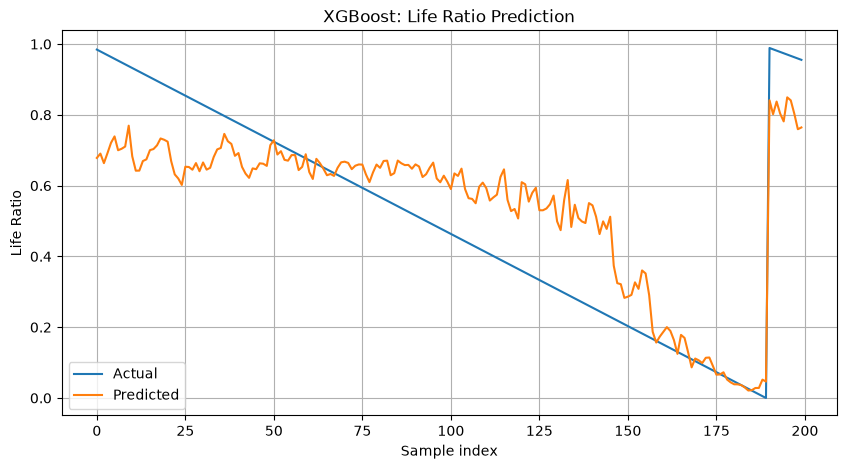

In [36]:
# Plot prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_pred_val[:200], label="Predicted")
plt.title("XGBoost: Life Ratio Prediction")
plt.ylabel("Life Ratio")
plt.xlabel("Sample index")
plt.legend()
plt.grid()
plt.show()

## Model comparison table

Validation-set results (target: `life_ratio`, bounded in [0, 1]), comparing this notebook
(no `cycle`) against step3 (with `cycle`):

| Model | Dataset | RMSE (with cycle) | RMSE (no cycle) | R² (with cycle) | R² (no cycle) |
|---|---|---:|---:|---:|---:|
| Random Forest (Optuna-tuned) | Validation | 0.0576 | 0.1785 | 0.9593 | 0.6101 |
| XGBoost (Optuna-tuned) | Validation | 0.0561 | 0.1783 | 0.9615 | 0.6108 |
| XGBoost (Optuna-tuned) | Test | 0.0669 | 0.1842 | 0.9137 | 0.3459 |

Removing `cycle` roughly **triples RMSE** and drags R² down from ~0.96 to ~0.61 on
validation, and from 0.91 to **0.35** on the (harder) test set. XGBoost and Random Forest
perform almost identically to each other without `cycle` (unlike step3, where XGBoost had
a small edge) -- with the dominant feature gone, both models are now limited by the same
thin sensor-only signal rather than by which algorithm is used.

### Interpretable / Explainable predictions using SHAP

In [37]:
import shap

X_sample = X_val.sample(n=10, random_state=42)

explainer = shap.TreeExplainer(best_xg)
shap_values = explainer(X_sample)



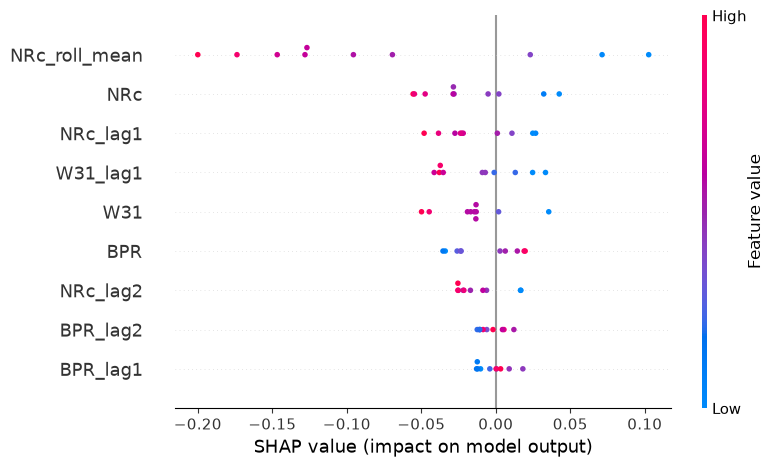

In [38]:
shap.plots.beeswarm(shap_values)

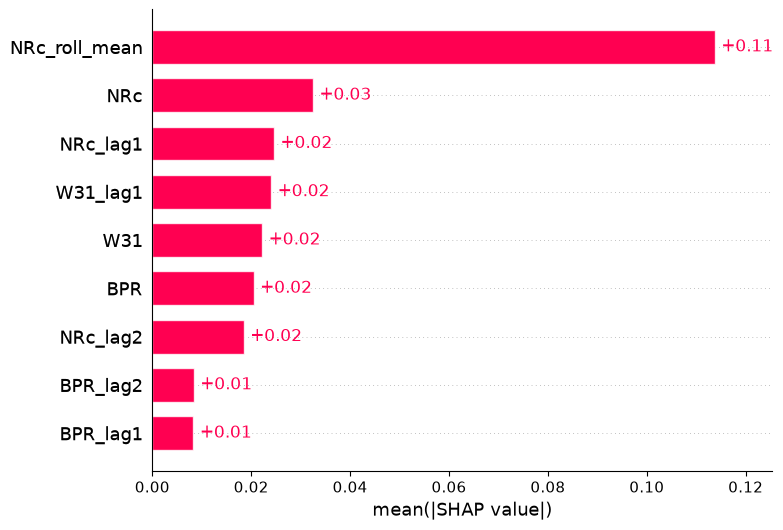

In [39]:
shap.plots.bar(shap_values)

Without `cycle` as a candidate feature, `NRc_roll_mean` becomes by far the dominant
contributor (mean |SHAP| ≈ 0.11, roughly 3-4x every other feature), followed by `NRc` and
its lags, then `W31` and `BPR` and their lags/rolling means -- the same features step3
already flagged as the next-most-important after `cycle`. Note `engine_id` also occupies
one of the 10 "selected" slots here (and in step3): its huge variance inflates its
correlation*variance score despite ~0 real correlation, but it's always dropped before
`X_train`/`X_val` are built, so it never actually reaches the model -- it just wastes a
selection slot that would otherwise go to a 10th real sensor feature.

# Evaluation on test set

In [40]:
import pandas as pd
from src.const import SENSOR_NAMES

# Read raw test data using the same schema as the training data
columns = ["engine_id", "cycle"] + SENSOR_NAMES

# Load the raw test file and the provided RUL values
raw_test = pd.read_csv(
    "../data/raw/test_FD001.txt",
    sep=r"\s+",
    header=None,
    usecols=range(len(columns)),
    names=columns,
    engine="python",
)
raw_rul = pd.read_csv("../data/raw/RUL_FD001.txt", sep=r"\s+", header=None).iloc[:, 0]

# Reconstruct RUL for every observed cycle using the provided terminal RUL values.
# The test set is censored (it doesn't run to failure), so life_ratio can't be
# computed with add_life_ratio() alone -- we need the true total life first.
engine_ids = raw_test["engine_id"].unique()
if len(raw_rul) != len(engine_ids):
    raise ValueError(f"Expected {len(engine_ids)} RUL values, got {len(raw_rul)}")

rul_map = dict(zip(engine_ids, raw_rul.tolist()))
raw_test["rul_at_last_cycle"] = raw_test["engine_id"].map(rul_map)
raw_test["last_cycle"] = raw_test.groupby("engine_id")["cycle"].transform("max")
raw_test["RUL"] = raw_test["rul_at_last_cycle"] + (raw_test["last_cycle"] - raw_test["cycle"])

# Total life = last observed cycle + the RUL still remaining at that cycle
raw_test["total_life"] = raw_test["last_cycle"] + raw_test["rul_at_last_cycle"]
raw_test["life_ratio"] = raw_test["RUL"] / raw_test["total_life"]
raw_test = raw_test.drop(columns=["rul_at_last_cycle", "last_cycle", "RUL", "total_life"])

# Apply the same column drops as training data (skip preprocess(), which assumes
# the dataframe runs to failure -- not true for this censored test set)
raw_test = clean_features(raw_test, cols_to_drop=cols_to_drop)

# Scale using the training-set scaler and create the same engineered features
sensor_cols = get_sensor_columns(raw_test)
raw_test_scaled = raw_test.copy()
raw_test_scaled[sensor_cols] = scaler.transform(raw_test_scaled[sensor_cols])

raw_test_fe = add_time_series_features(raw_test_scaled, sensor_cols)
raw_test_fe = raw_test_fe.dropna().reset_index(drop=True)

# Keep the same feature columns used during model training
raw_test_final = apply_feature_selection(raw_test_fe, selected_features, target="life_ratio")

# Collect processed test data for later evaluation
test_data_processed = [raw_test_final]
test_data_processed = pd.concat(test_data_processed, ignore_index=True)

print("Test preprocessing complete.")
test_data_processed.head()

Test preprocessing complete.


,life_ratio,engine_id,NRc,NRc_lag1,BPR,NRc_lag2,BPR_lag1,BPR_lag2,NRc_roll_mean,W31,W31_lag1,cycle
0,0.979021,1,-0.149293,-0.149293,0.752310,-1.278278,1.010825,0.412159,-0.525621,-0.132811,-0.132811,3
1,0.972028,1,-0.977215,-0.149293,-0.050446,-0.149293,0.752310,1.010825,-0.638520,-1.426246,-0.132811,4
2,0.965035,1,-0.864317,-0.977215,0.997219,-0.149293,-0.050446,0.752310,-0.683679,-2.072963,-1.426246,5
3,0.958042,1,-1.052481,-0.864317,0.684280,-0.977215,0.997219,-0.050446,-0.638520,-0.779529,-2.072963,6
4,0.951049,1,-0.864317,-1.052481,0.806734,-0.864317,0.684280,0.997219,-0.781525,-1.426246,-0.779529,7


In [41]:
train_final.columns

Index(['life_ratio', 'engine_id', 'NRc', 'NRc_lag1', 'BPR', 'NRc_lag2',
       'BPR_lag1', 'BPR_lag2', 'NRc_roll_mean', 'W31', 'W31_lag1', 'cycle'],
      dtype='object')

In [42]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare features and target for evaluation
X_test = test_data_processed.drop(columns=["life_ratio", "engine_id", "cycle"], errors="ignore")
y_test = test_data_processed["life_ratio"]

# Use the trained model from the notebook
if "best_xg" not in globals():
    raise NameError("Train a model first (for example, fit best_xg on X_train/y_train).")

# Predict on the test set
y_pred_test = best_xg.predict(X_test)

# Compute evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("\nTest Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")


Test Performance:
RMSE: 0.1842
MAE : 0.1517
R2  : 0.3459


# Error Analysis

Mean test residual (Actual - Predicted): 0.036638931821567314


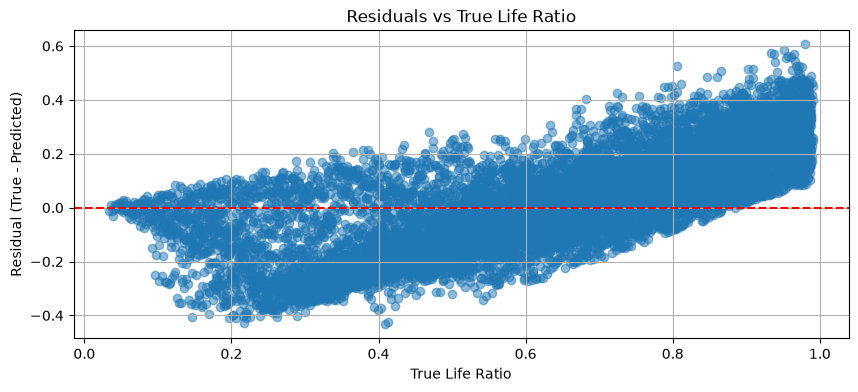

In [43]:
residuals = y_test - y_pred_test
print("Mean test residual (Actual - Predicted):", residuals.mean())

plt.figure(figsize=(10, 4))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("True Life Ratio")
plt.ylabel("Residual (True - Predicted)")
plt.title("Residuals vs True Life Ratio")
plt.grid(True)
plt.show()

Without `cycle`, the mean test residual is about **+0.037** (Actual - Predicted, a mild
underprediction on average) -- similar in *sign* to step3's +0.010, but the residual
scatter (above) is dramatically wider: errors of ±0.4-0.6 are common for engines still
early in their life, whereas step3's residuals stayed tightly clustered near 0 across the
whole life_ratio range. The model no longer has a direct signal for "how far along is this
engine," so it can only really trust the sensors once degradation becomes visible.

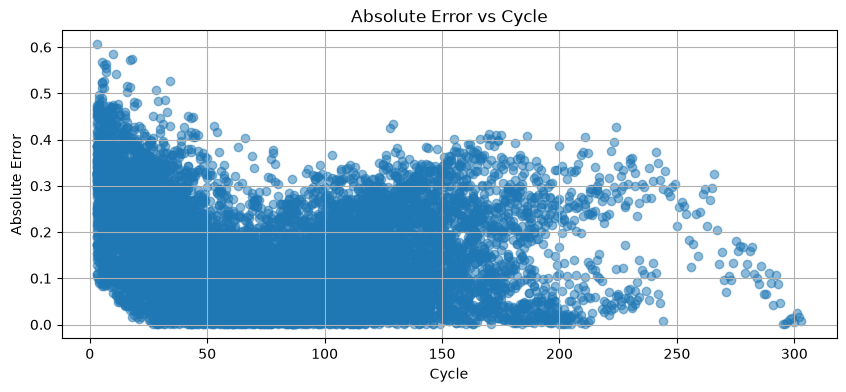

In [44]:
### Error by cycle
plt.figure(figsize=(10, 4))
plt.scatter(test_data_processed["cycle"], np.abs(residuals), alpha=0.5)
plt.xlabel("Cycle")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Cycle")
plt.grid(True)
plt.show()


Error is still lower near failure (high cycle counts) and higher early in an engine's
life, same qualitative pattern as step3 -- but the magnitudes are now much larger overall
(errors up to ~0.6 early on, vs a small fraction of that in step3). Near failure, sensor
degradation is pronounced enough that the model does almost as well without `cycle`; far
from failure, sensors alone carry little signal about remaining life, and `cycle` was
doing most of that work in step3.

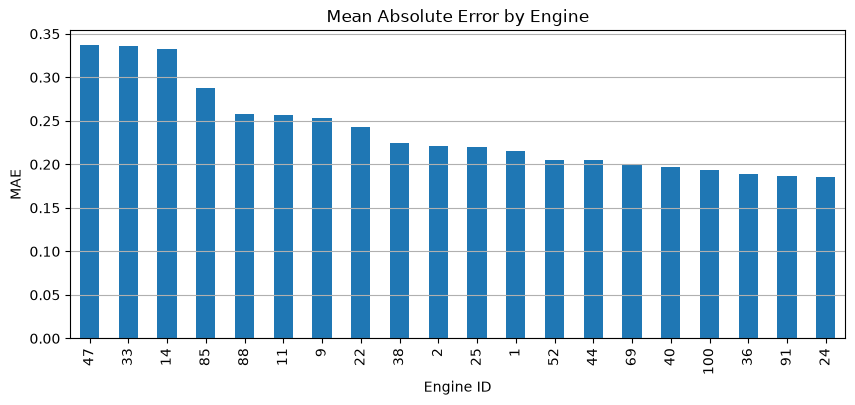

In [45]:
### Error by engine
engine_errors = pd.DataFrame({
    "engine_id": test_data_processed["engine_id"],
    "abs_error": np.abs(residuals)
}).groupby("engine_id")["abs_error"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
engine_errors.head(20).plot(kind="bar")
plt.title("Mean Absolute Error by Engine")
plt.ylabel("MAE")
plt.xlabel("Engine ID")
plt.grid(axis="y")
plt.show()

Engine 47 has the highest errors (MAE ≈ 0.34), versus engine 93 in step3 -- a
different worst engine, consistent with the model now leaning on a different (weaker)
signal.

# Classification Evaluation via binning


When life_ratio is below 0.1 (10% of life remaining), we treat the engine as being in a near-failure state and flag it for maintenance attention. This is often more actionable from a business perspective than reporting a raw life_ratio number, because it supports clear operational decisions such as scheduling inspection, maintenance, or replacement.

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report

# Note: threshold should not be tuned using test set
def binary_evaluation(threshold=0.1, pred_offset=0.0):
    # Convert continuous life_ratio into a binary class: 1 = near failure, 0 = not near failure
    y_true_bin = (y_test <= threshold).astype(int)
    y_pred_bin = (y_pred_test <= threshold + pred_offset).astype(int)

    accuracy = accuracy_score(y_true_bin, y_pred_bin)
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    cm = confusion_matrix(y_true_bin, y_pred_bin)

    print("Binary Classification Metrics")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true_bin, y_pred_bin, target_names=["Not Near Failure", "Near Failure"]))

    # Optional: plot confusion matrix
    import seaborn as sns
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Near Failure", "Near Failure"], yticklabels=["Not Near Failure", "Near Failure"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix for Near-Failure Classification")
    plt.show()

Binary Classification Metrics
Accuracy : 0.9946
Precision: 0.7182
Recall   : 0.6752
F1-score : 0.6960

Classification Report:
                  precision    recall  f1-score   support

Not Near Failure       1.00      1.00      1.00     12779
    Near Failure       0.72      0.68      0.70       117

        accuracy                           0.99     12896
       macro avg       0.86      0.84      0.85     12896
    weighted avg       0.99      0.99      0.99     12896



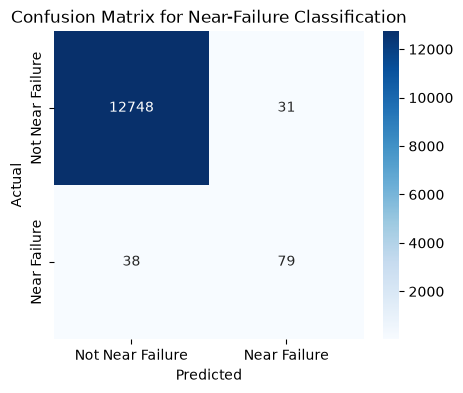

In [47]:
binary_evaluation()

Binary Classification Metrics
Accuracy : 0.9886
Precision: 0.4390
Recall   : 0.9231
F1-score : 0.5950

Classification Report:
                  precision    recall  f1-score   support

Not Near Failure       1.00      0.99      0.99     12779
    Near Failure       0.44      0.92      0.60       117

        accuracy                           0.99     12896
       macro avg       0.72      0.96      0.79     12896
    weighted avg       0.99      0.99      0.99     12896



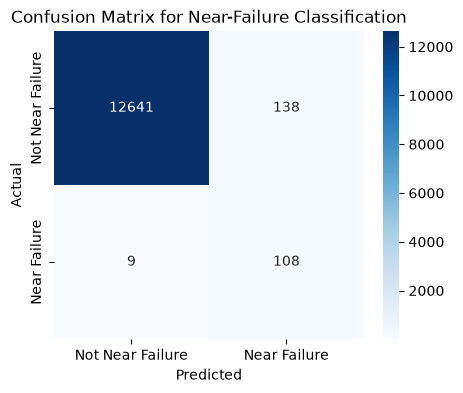

In [48]:
binary_evaluation(pred_offset=0.05)

Because life_ratio is bounded in [0, 1], a prediction offset here is a small ratio
(e.g. 0.05) rather than a cycle count. As before, increasing the offset improves recall
at the cost of precision, letting the business choose the tradeoff between catching more
at-risk engines and tolerating more false alarms. These numbers are close to step3's
(with `cycle`) despite the much worse regression metrics above -- near-failure sensor
degradation alone is nearly enough to flag risk, even without `cycle`.

Example (this notebook, no `cycle`):

Model with offset=0:
- precision = 0.72
- recall = 0.68

Model with offset=0.05:
- precision = 0.44
- recall = 0.92

# Verdict: does the model still perform as well without `cycle`?

**No.** Removing `cycle` as a model input roughly **triples RMSE** and drags R² down
from ~0.96 to ~0.61 on validation, and from 0.91 to **0.35** on the test set (see the
model comparison table above). Optuna tuning barely helps once `cycle` is gone -- the
bottleneck is information, not hyperparameters.

The picture is more nuanced for the **binary near-failure classification** used for
maintenance flagging: accuracy, precision, recall, and F1 all stay within ~1-4 points of
step3's numbers. Sensor degradation alone is apparently enough to flag an engine as
*near* failure, even without a cycle counter -- it's *precisely locating* an engine
along its full life trajectory (the continuous life_ratio regression) that needs `cycle`.
This also matches the error-by-cycle plot: error is small near failure in both
notebooks, and the gap between them opens up early/mid-life, exactly where only `cycle`
(not yet-visible sensor degradation) told the original model how much life was left.

**Is this leakage?** No -- `cycle` is a legitimate, always-available feature in
production (it's just an operating-hours counter, not derived from the label in any
illegitimate way), unlike, say, a future sensor reading would be. The model isn't
"cheating"; it's correctly exploiting the strongest legitimate signal available. Given
that, and that removing it causes a large, real accuracy loss with no corresponding
benefit, **the recommendation is to keep `cycle` as a feature** -- the concern that
motivated this notebook (the model "relies too heavily" on it) is true in the sense that
`cycle` dominates SHAP importance, but that reliance is earned, not spurious.

The one caveat: if a production deployment can't guarantee an accurate, consistent
cycle count for every engine (e.g. a reset counter, missing history, a new fleet with no
baseline), this notebook shows what to expect -- a much weaker but not useless model,
still reasonably capable of flagging imminent failure from sensors alone even though its
continuous life-ratio estimates would be far less reliable.

# Verdict: Life ratio vs RUL

Life ratio often produces better RMSE, R², and classification performance in CMAPSS because it normalizes the degradation trajectory into a bounded and monotonic signal. This makes the learning problem easier by reducing target's variance and normalizing to a [0, 1] scale.

## Future work for model improvements

Several next steps could further improve the model and make the results more robust:

- Add a baseline model comparison table, including simple baselines and more advanced models, to better quantify the gain from the current approach.
- Run an ablation study for lag and rolling features to measure how much each feature group contributes to predictive performance.
- Combine multiple datasets or operating conditions to improve generalization and reduce overfitting to a single fleet or regime.
